<a href="https://www.kaggle.com/code/lalit7881/coffee-shop-sales-eda-100?scriptVersionId=351777439" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/srisyra02/coffee-shop-sales-dataset/Coffee Shop Sales.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/srisyra02/coffee-shop-sales-dataset/Coffee Shop Sales.csv")

In [3]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,1/1/23,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,1/1/23,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,1/1/23,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,1/1/23,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,1/1/23,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [4]:
df.tail()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
149111,149452,6/30/23,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,6/30/23,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,6/30/23,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,6/30/23,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino
149115,149456,6/30/23,20:57:19,2,8,Hell's Kitchen,64,0.80,Flavours,Regular syrup,Hazelnut syrup


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  object 
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 12.5+ MB


In [6]:
df.describe()

,transaction_id,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.542509,2.074241,17.930020,2.658723
min,1.000000,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2.000000,8.000000,60.000000,3.750000
max,149456.000000,8.000000,8.000000,87.000000,45.000000


In [7]:
df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

transaction_id        int64
transaction_date     object
transaction_time     object
transaction_qty       int64
store_id              int64
store_location       object
product_id            int64
unit_price          float64
product_category     object
product_type         object
product_detail       object
dtype: object

In [10]:
df.shape

(149116, 11)

In [11]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail'],
      dtype='object')

In [12]:
df.nunique()

transaction_id      149116
transaction_date       181
transaction_time     25762
transaction_qty          6
store_id                 3
store_location           3
product_id              80
unit_price              41
product_category         9
product_type            29
product_detail          80
dtype: int64

## EDA

Dataset Shape: (149116, 11)

Columns:
Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail'],
      dtype='object')

========== DATA INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  object 
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 1

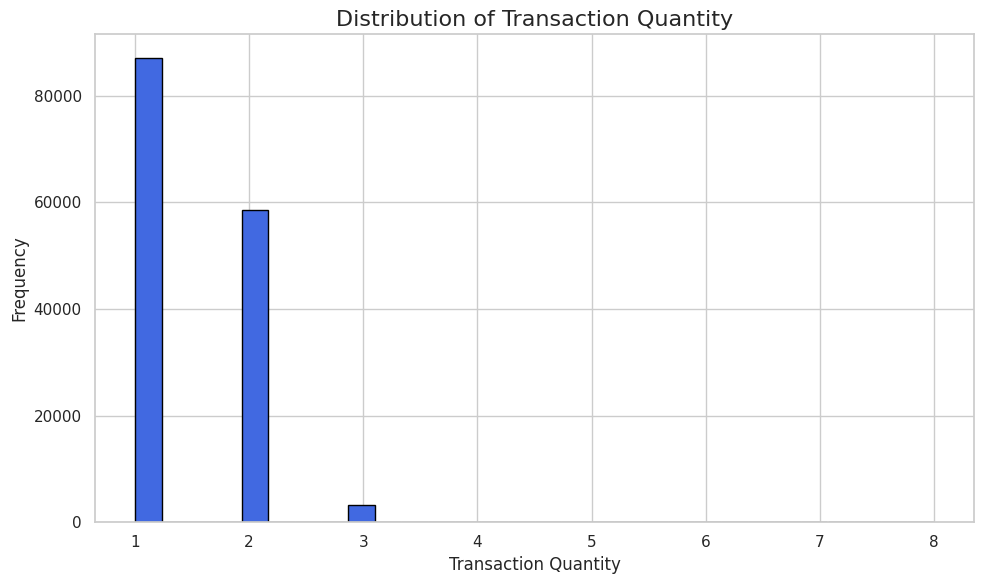

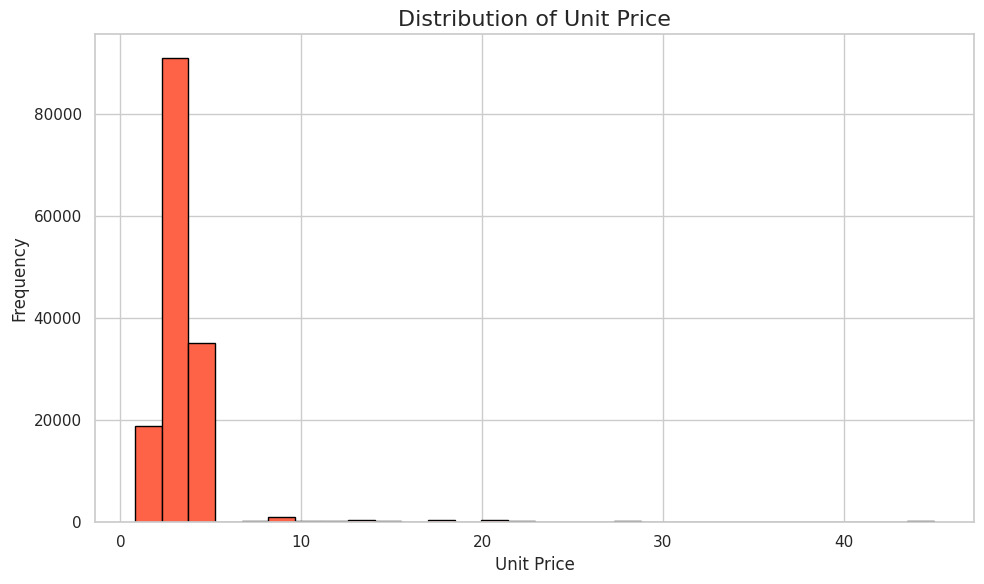

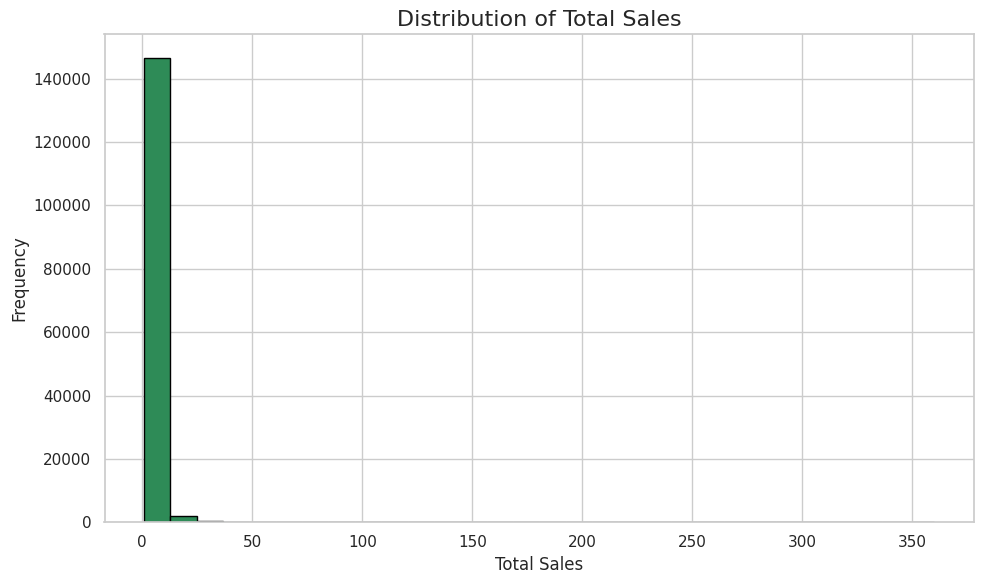

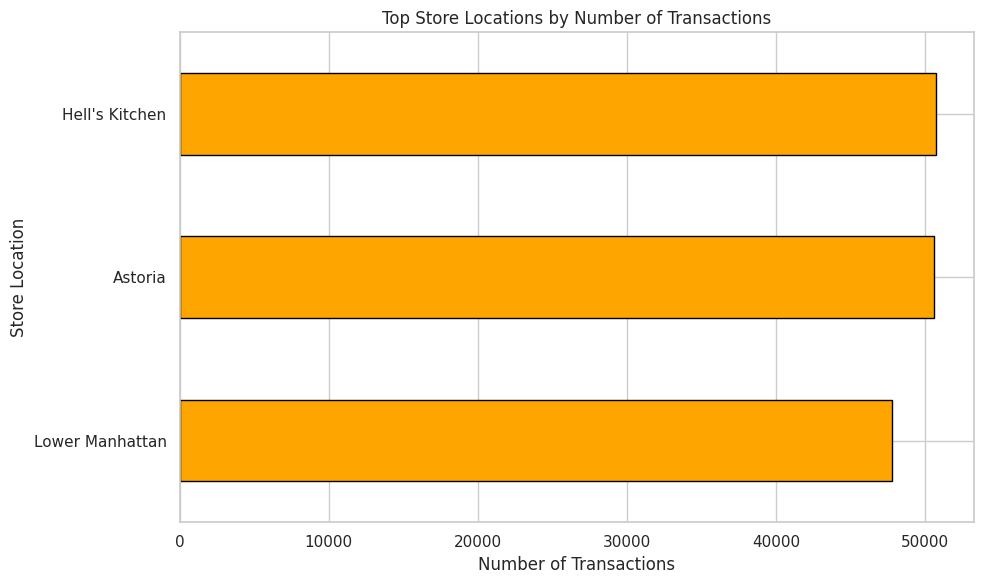

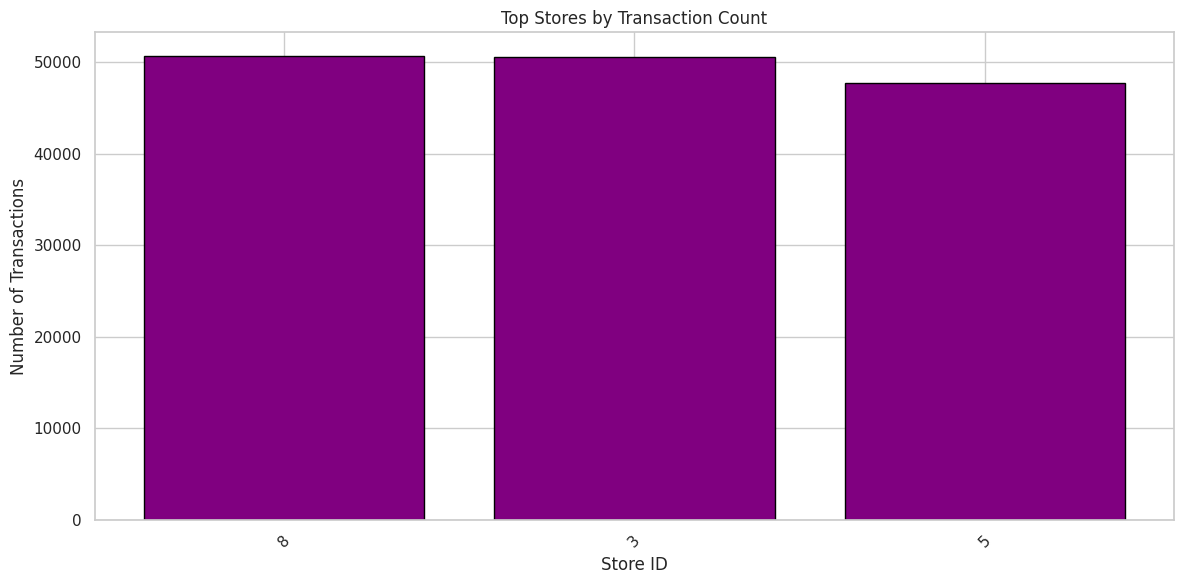

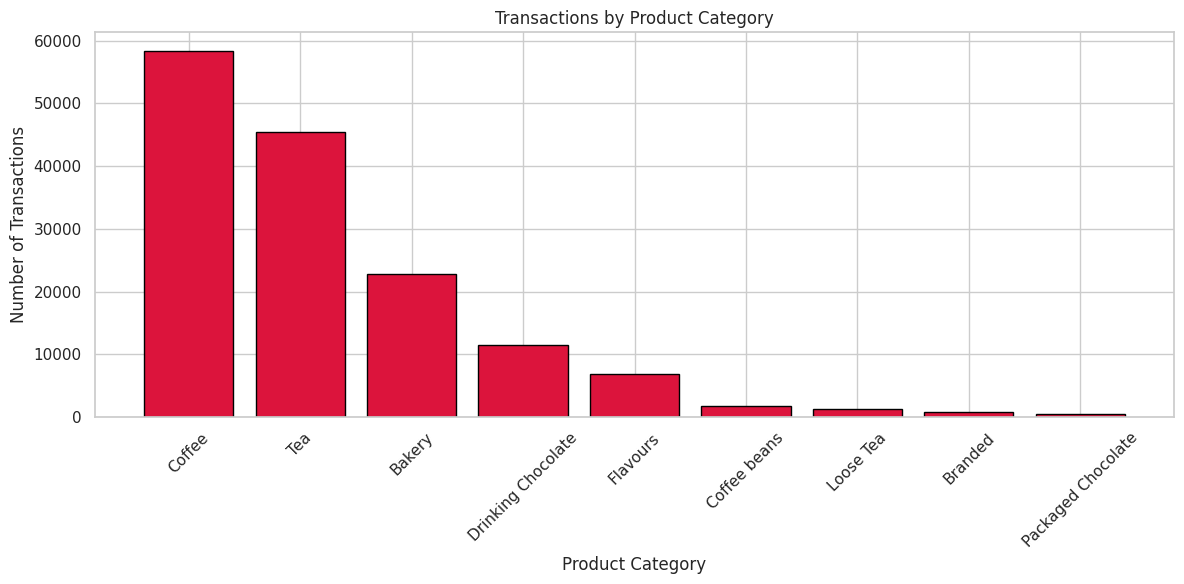

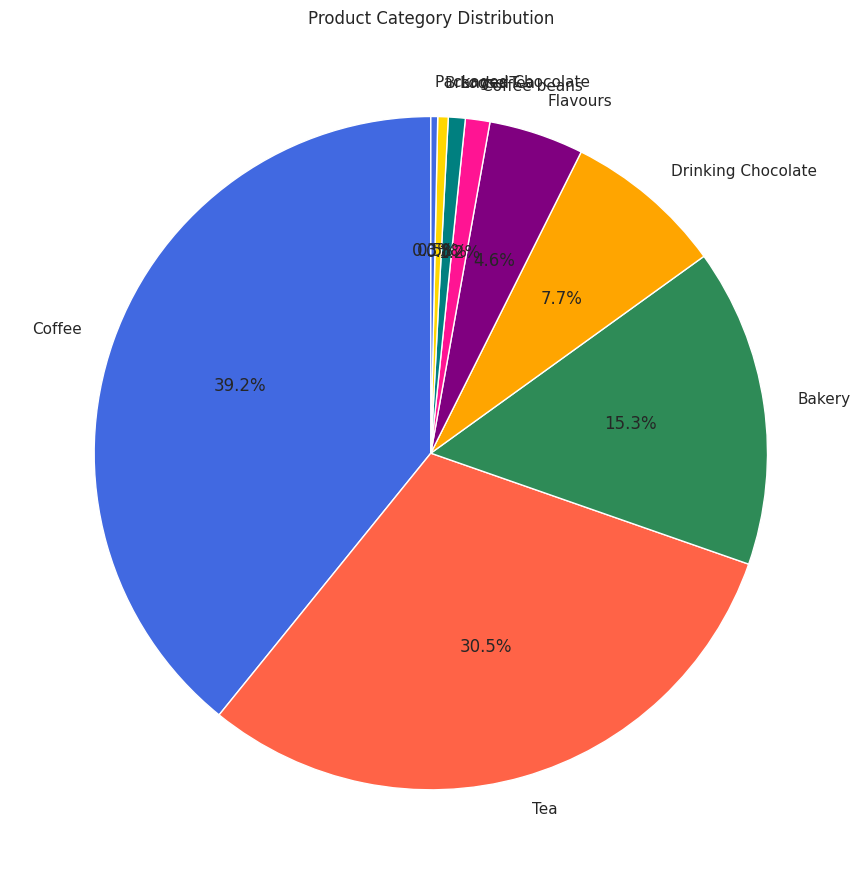

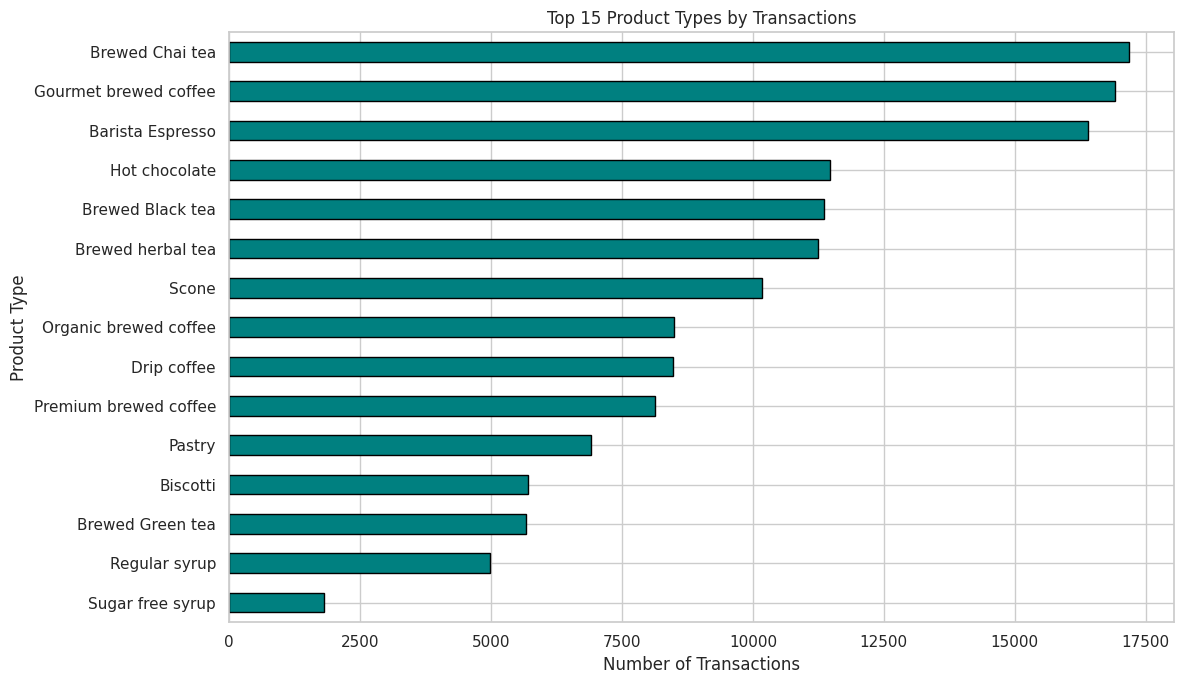

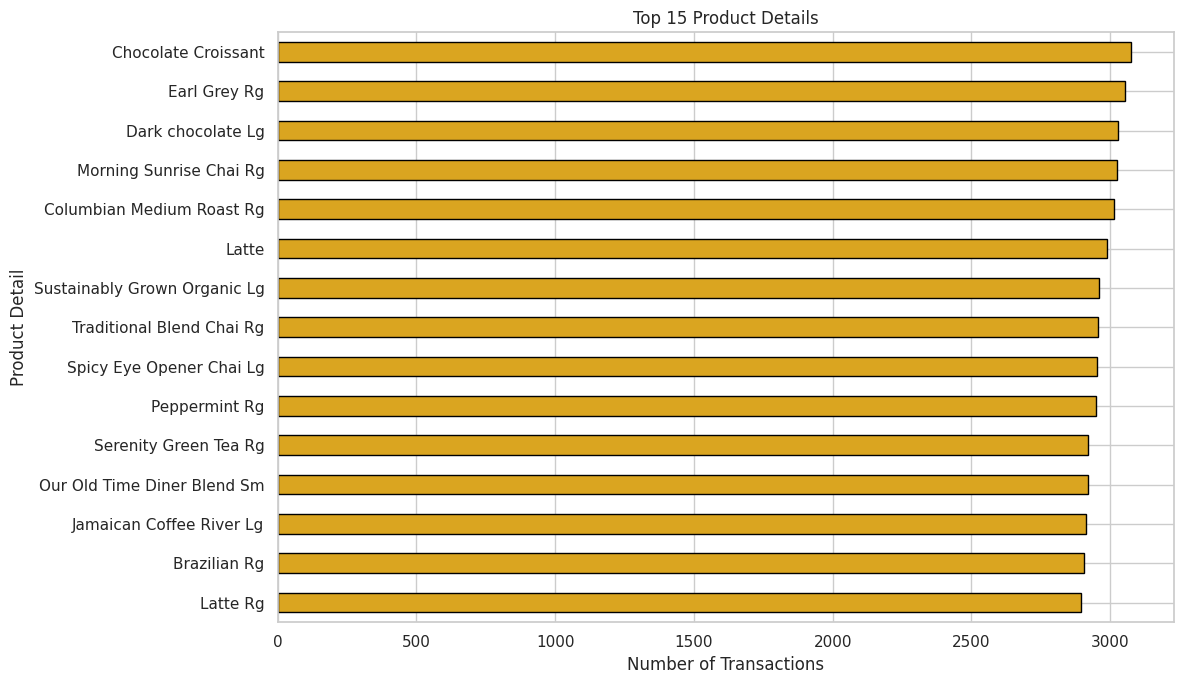

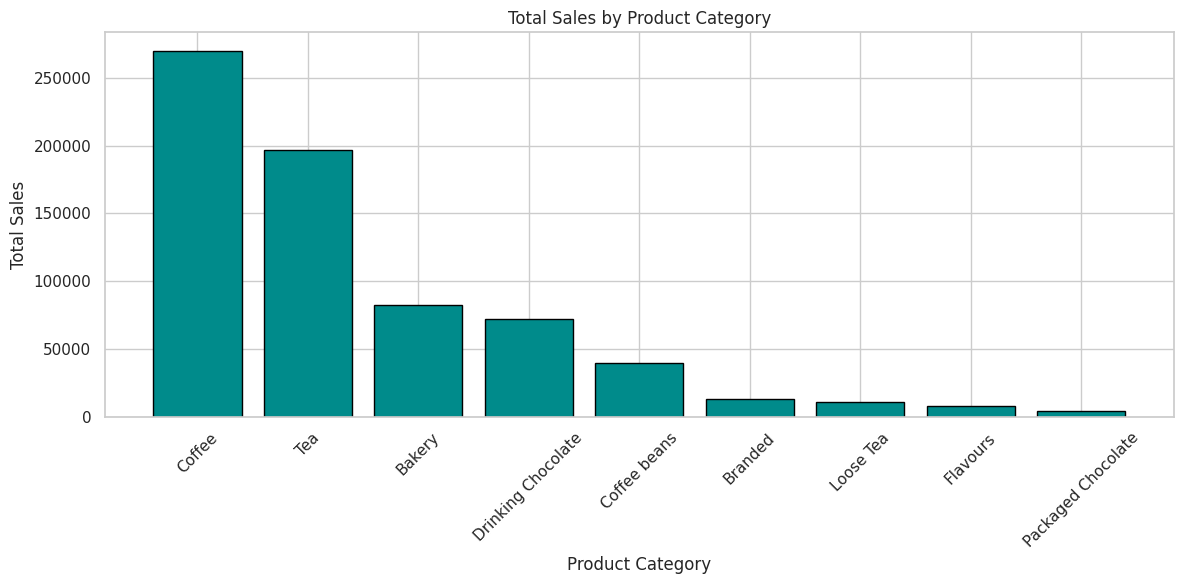

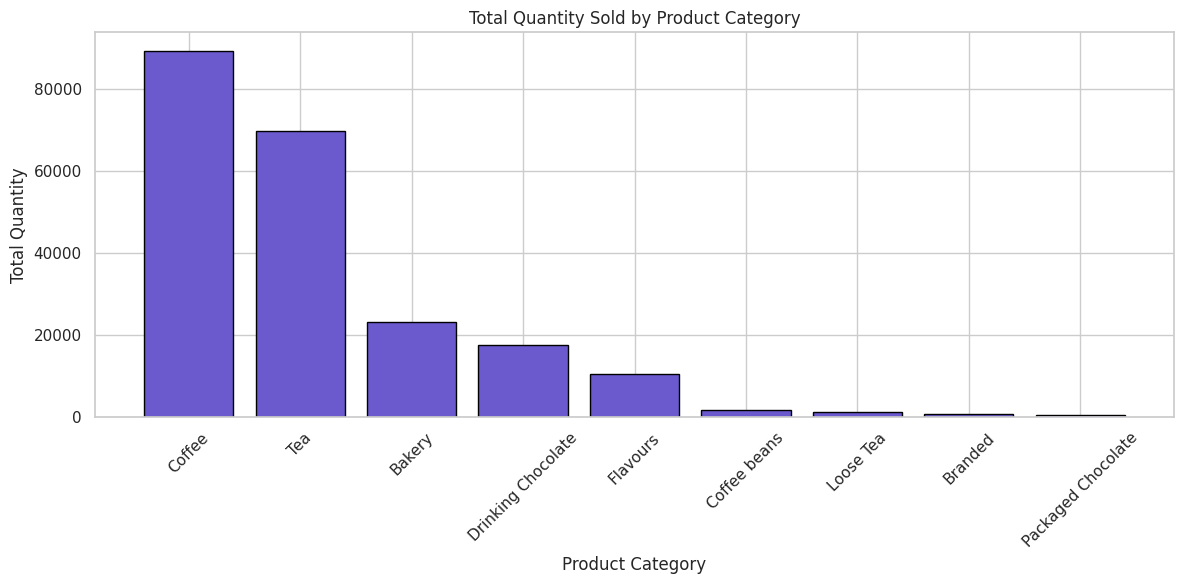

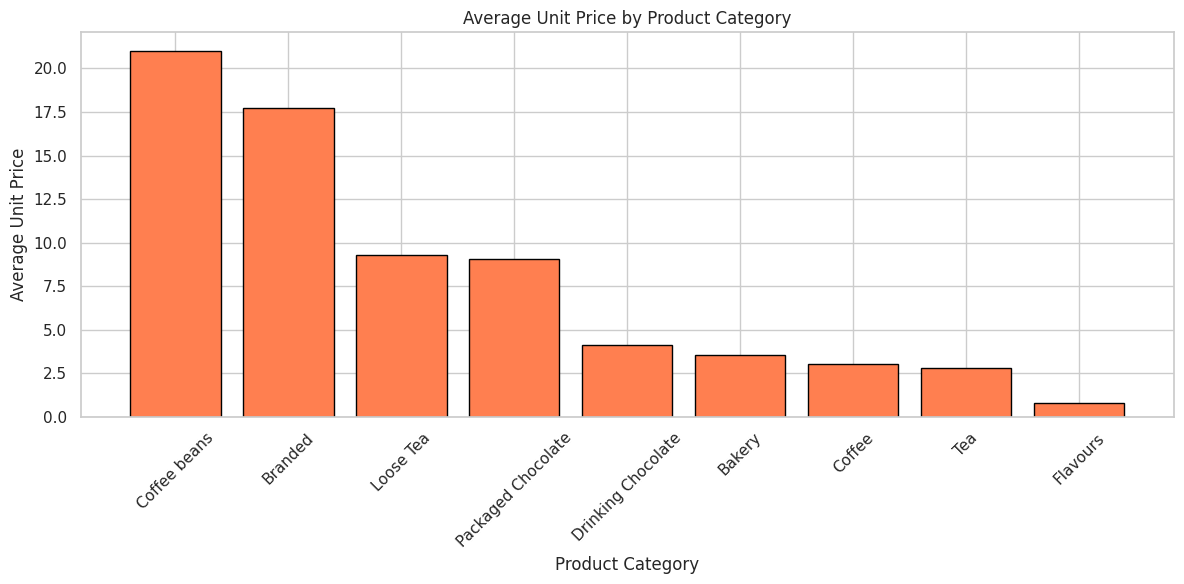

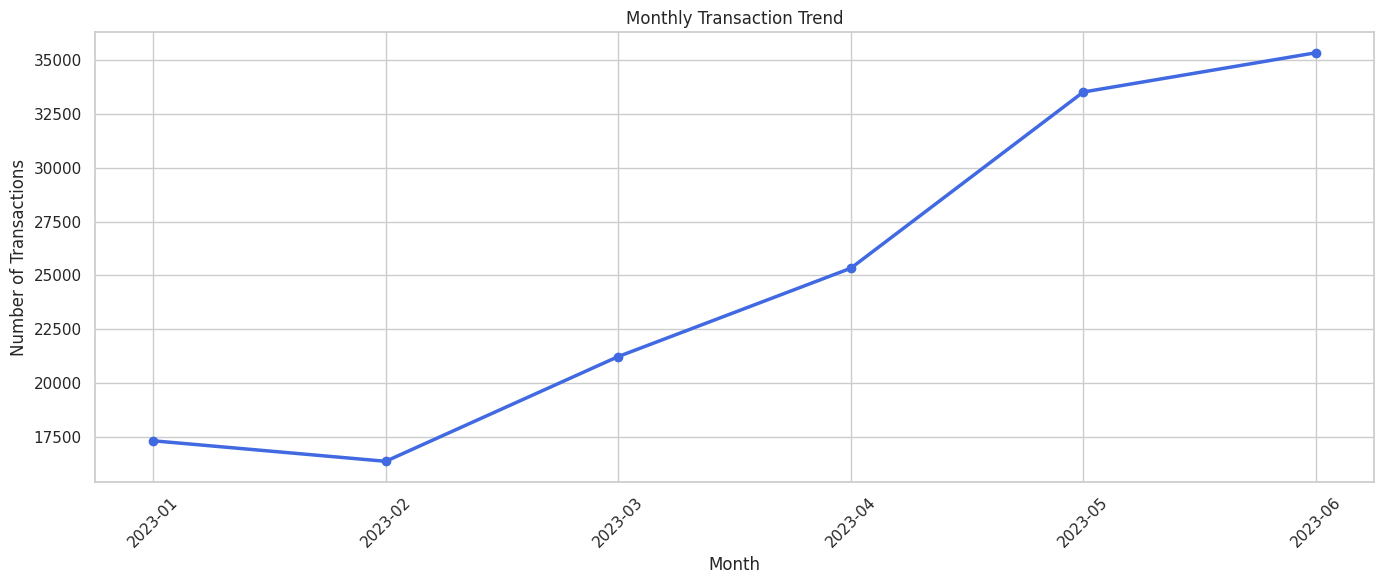

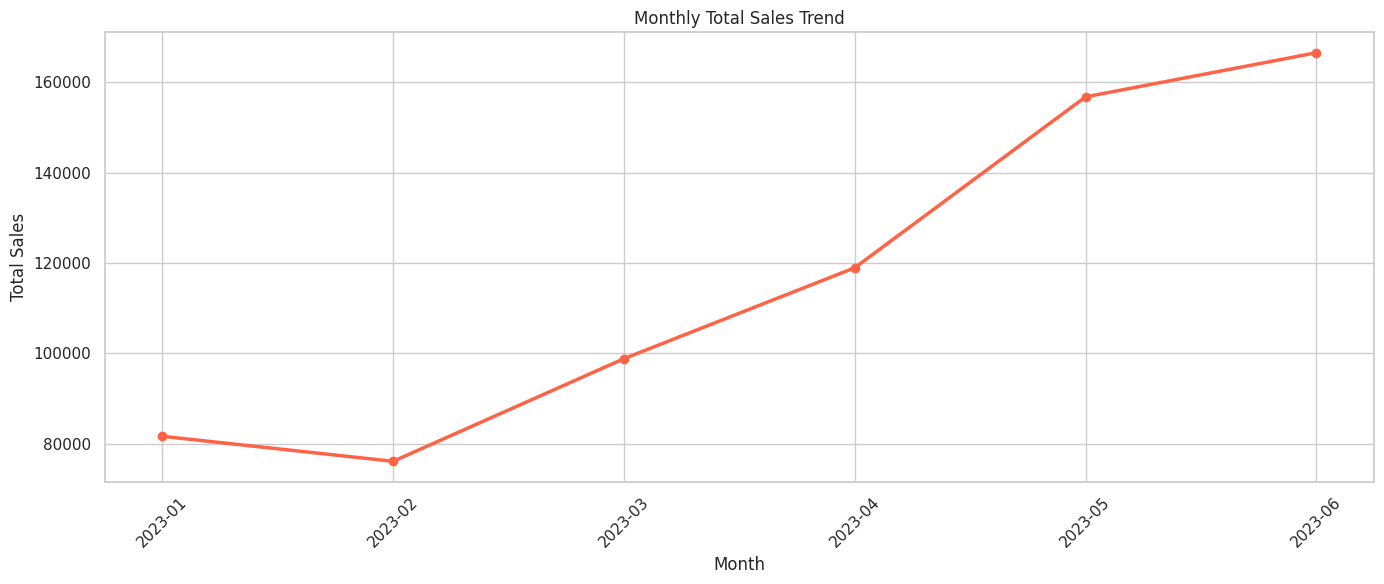

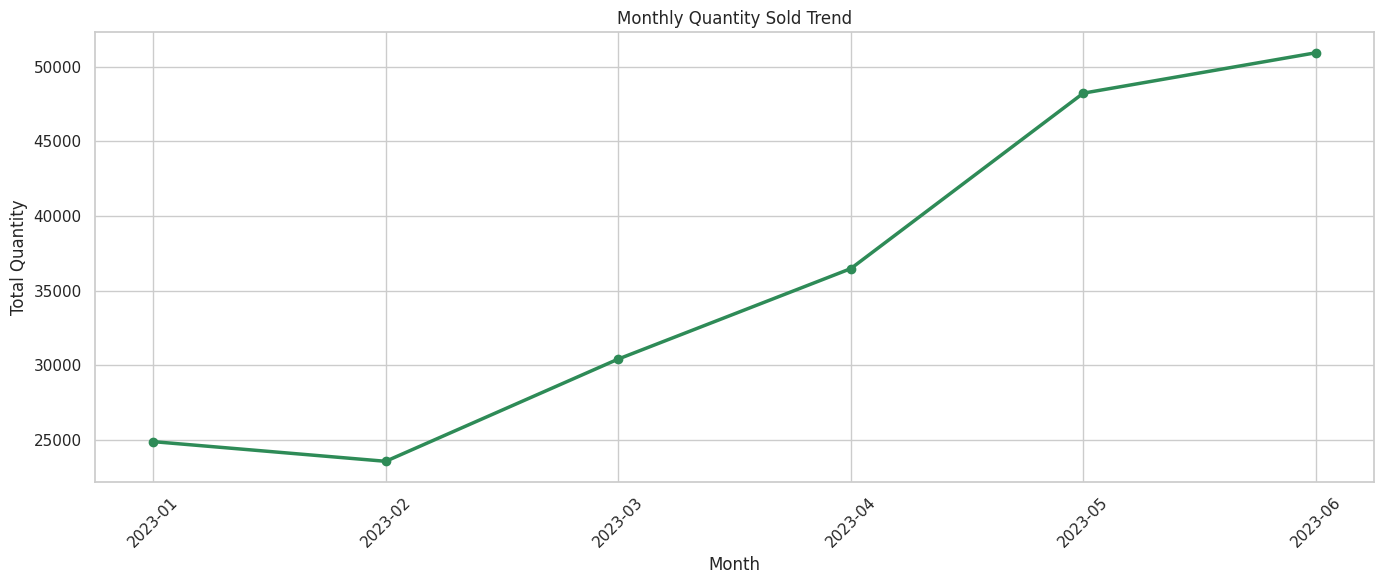

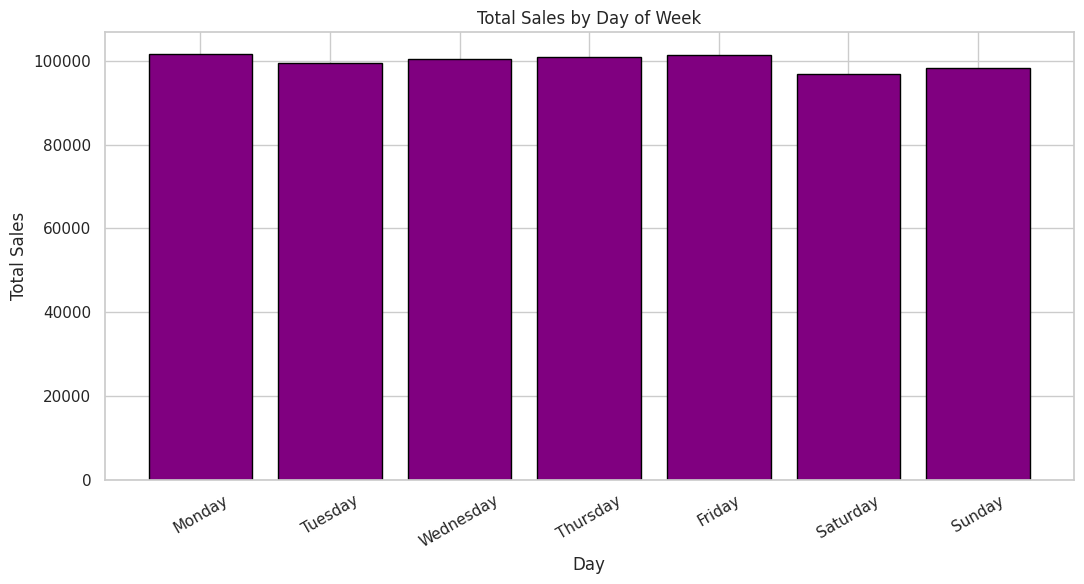

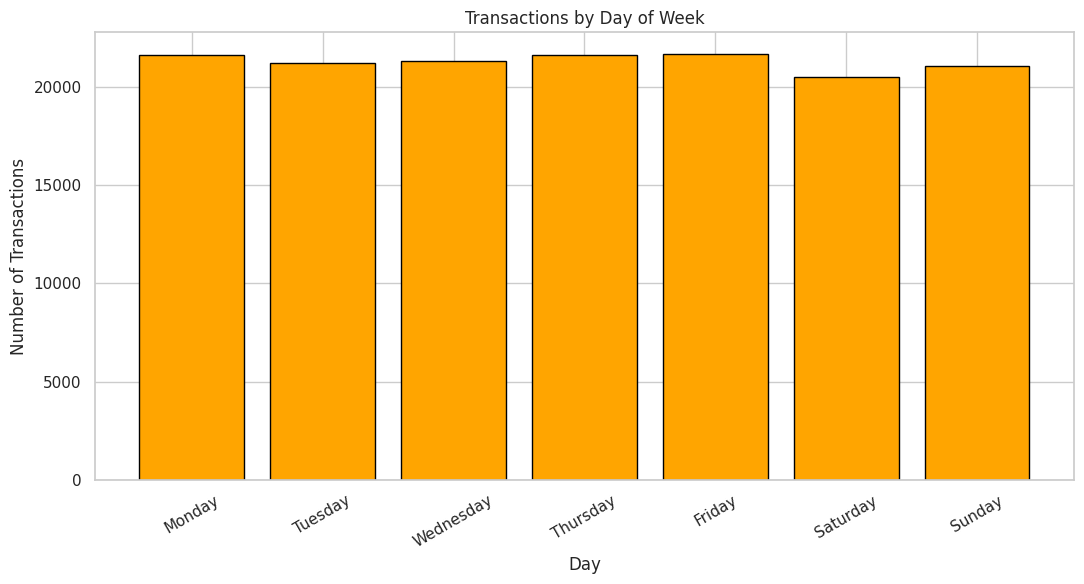

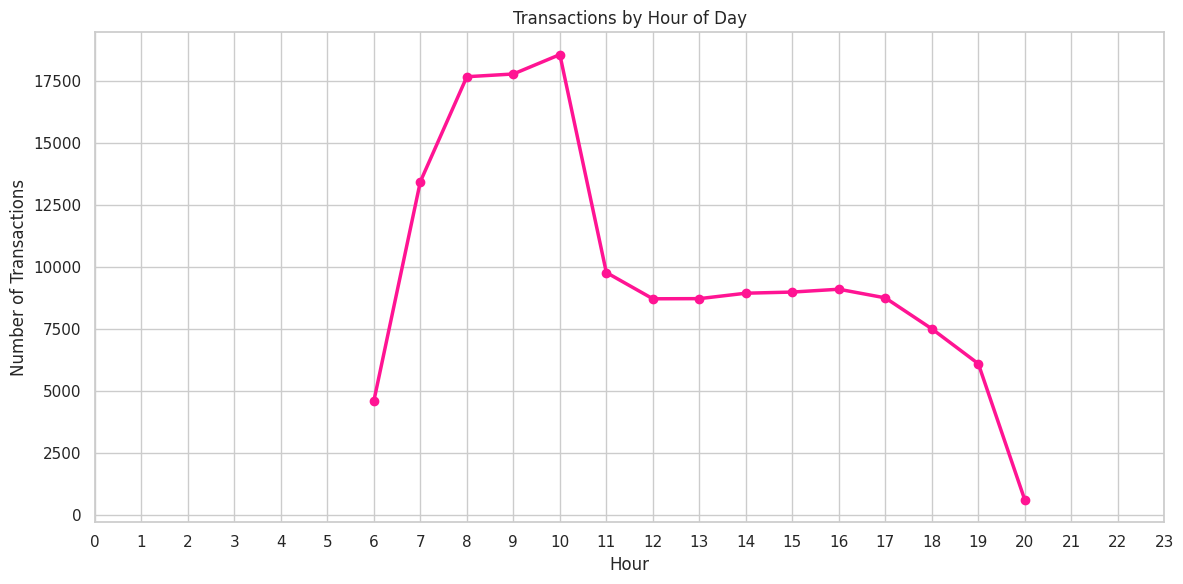

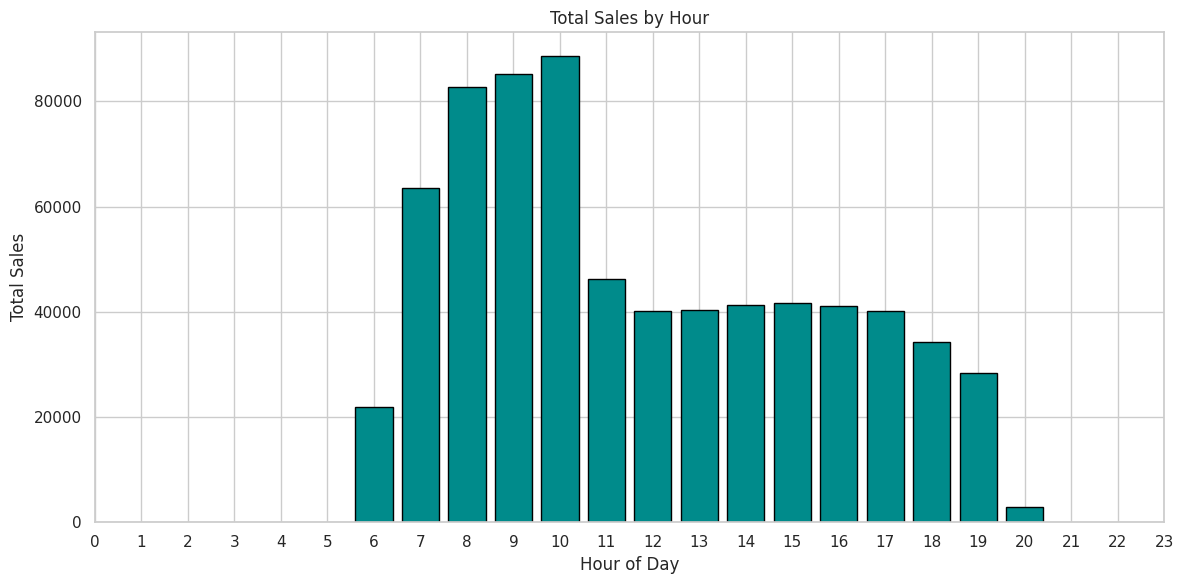

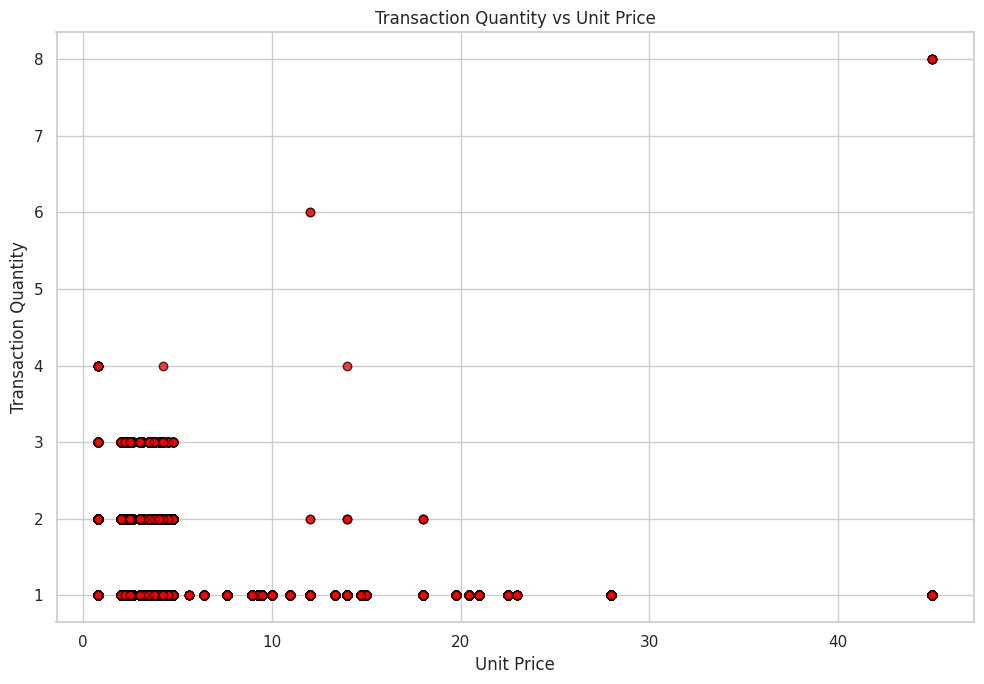

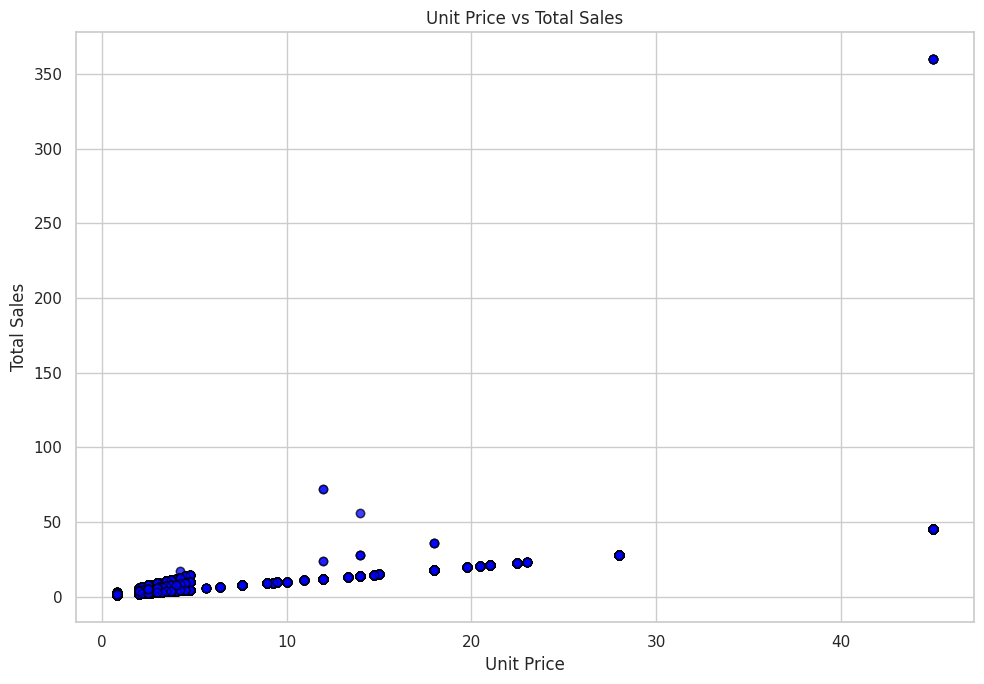

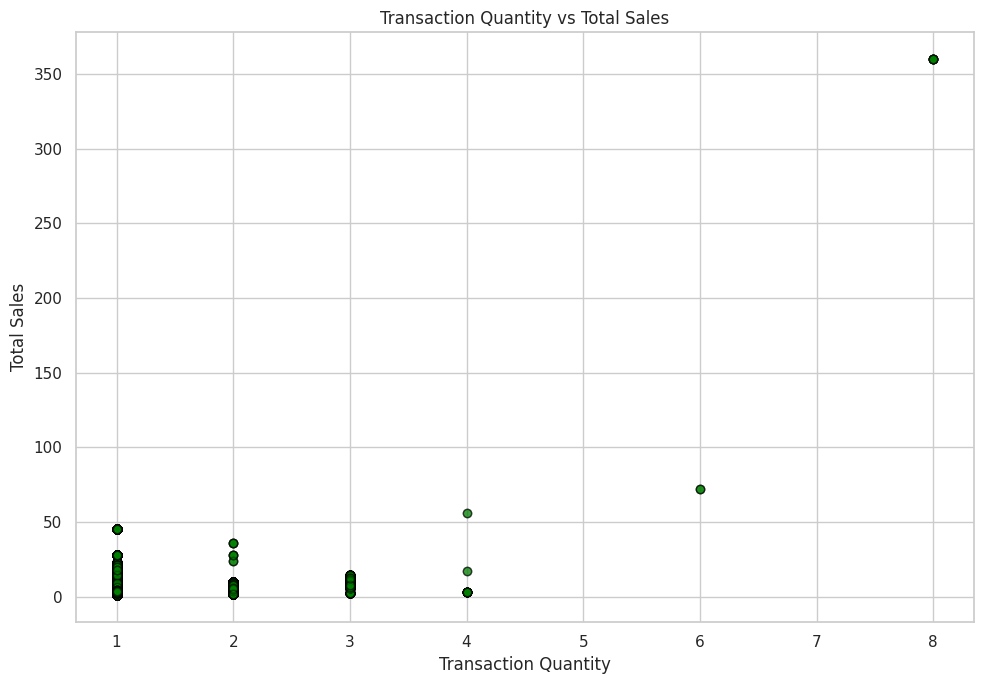

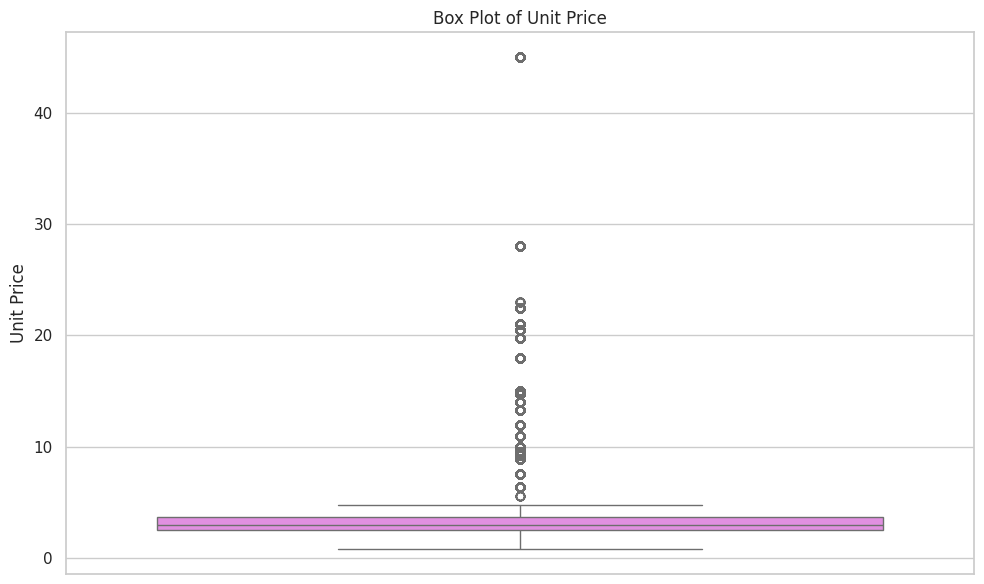

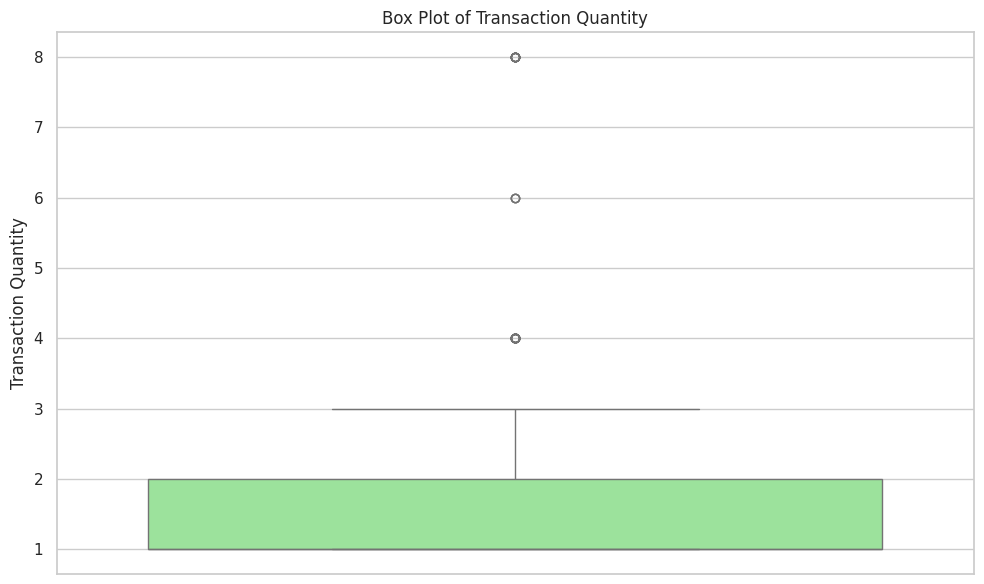

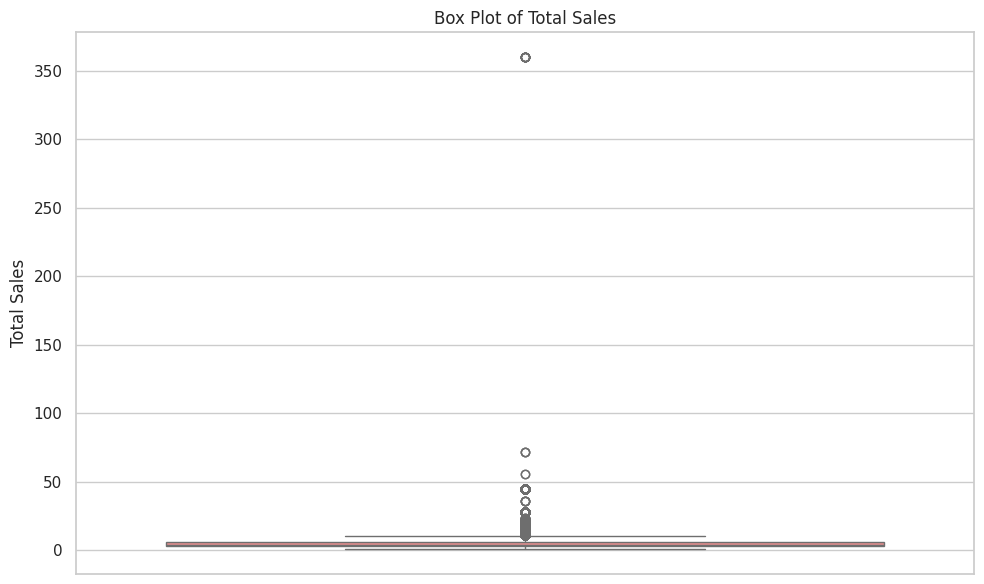

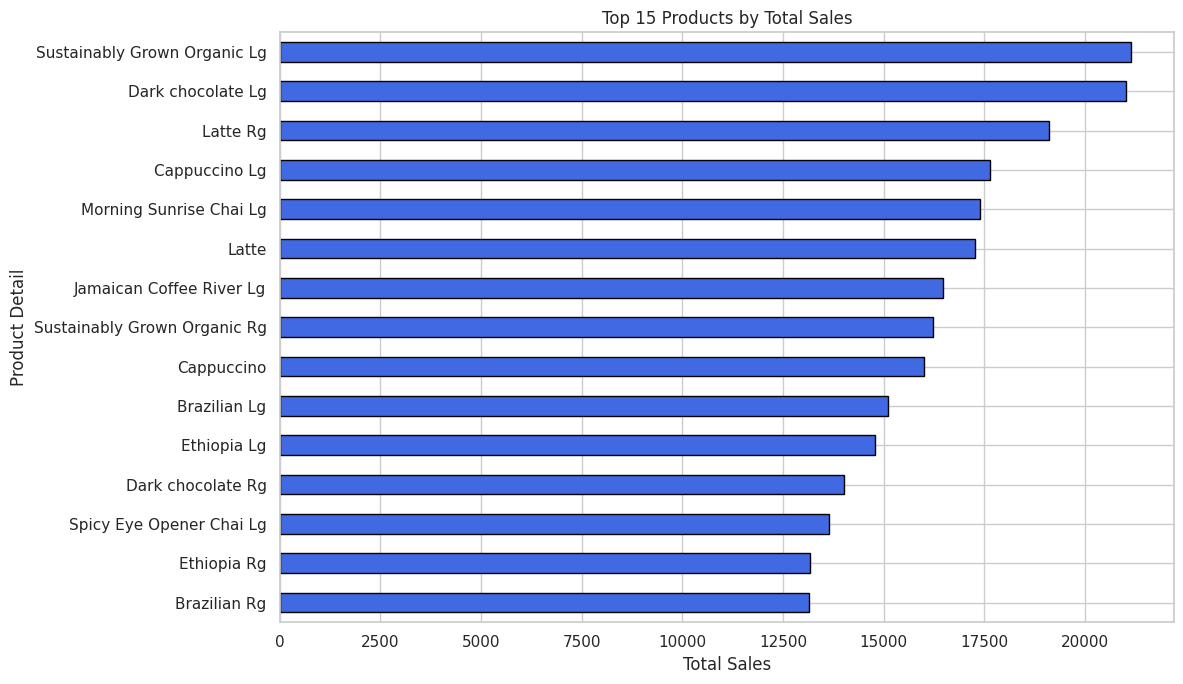

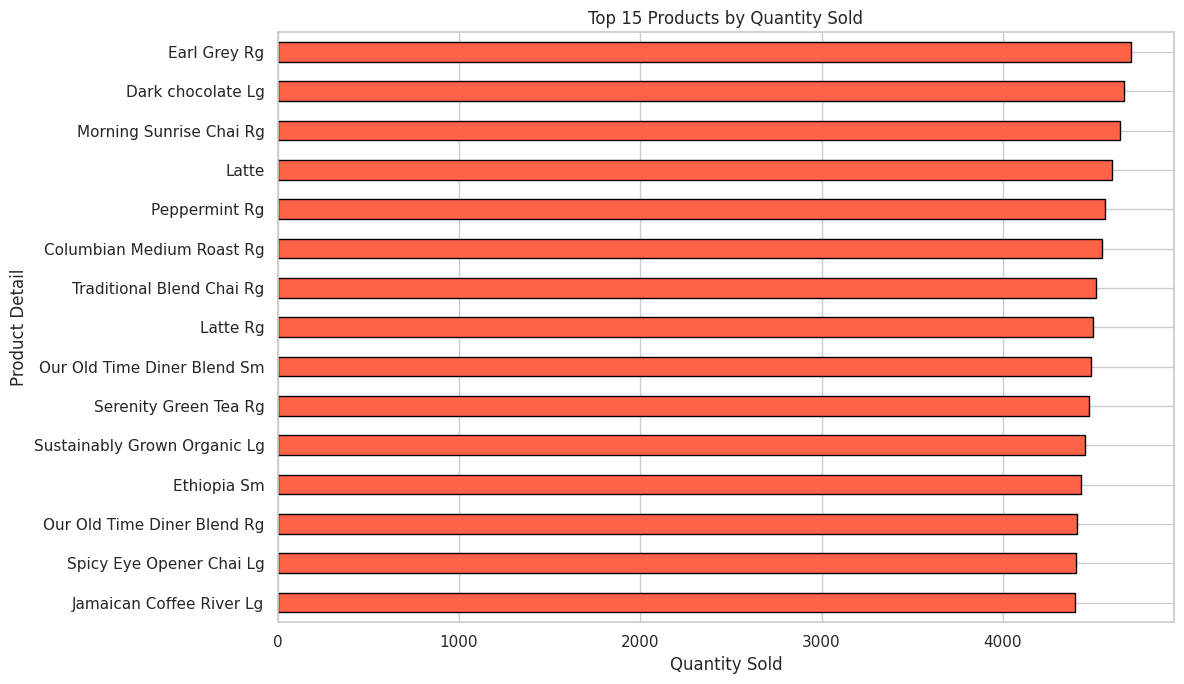

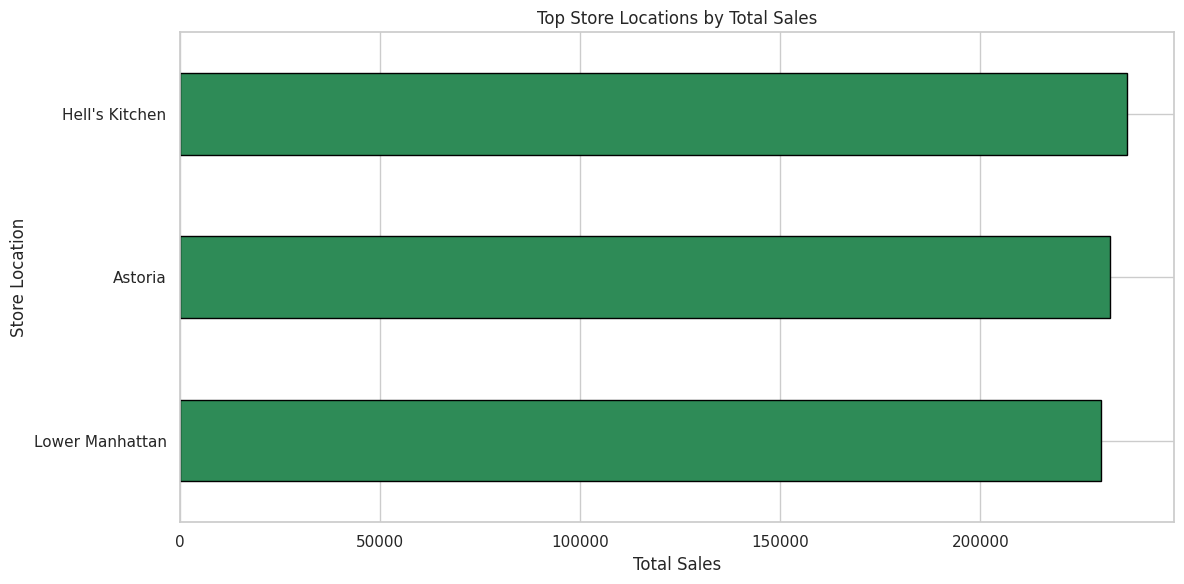

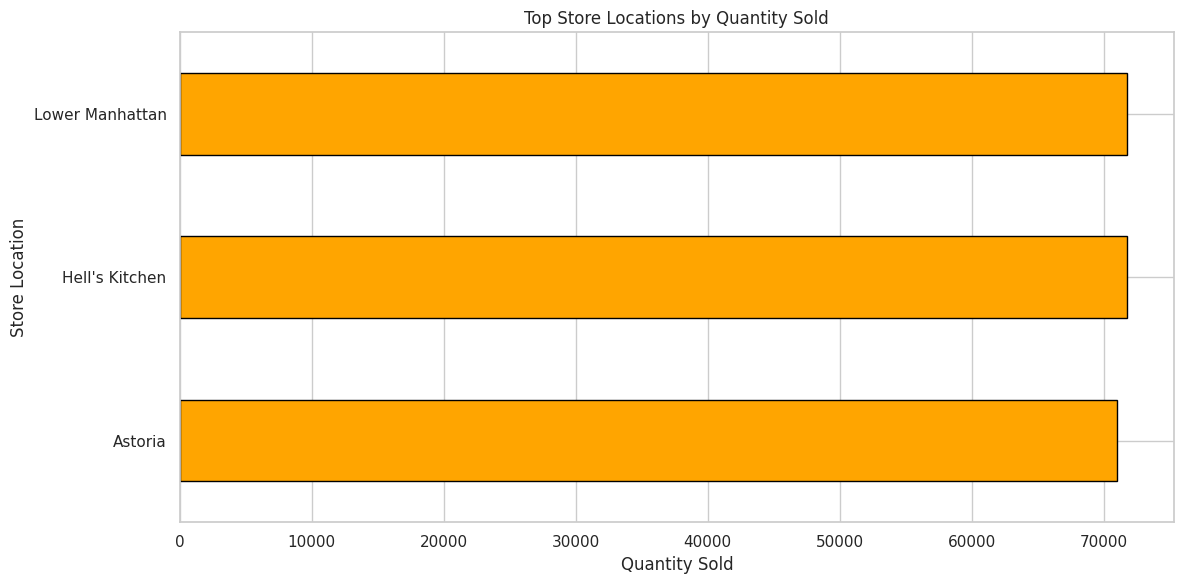

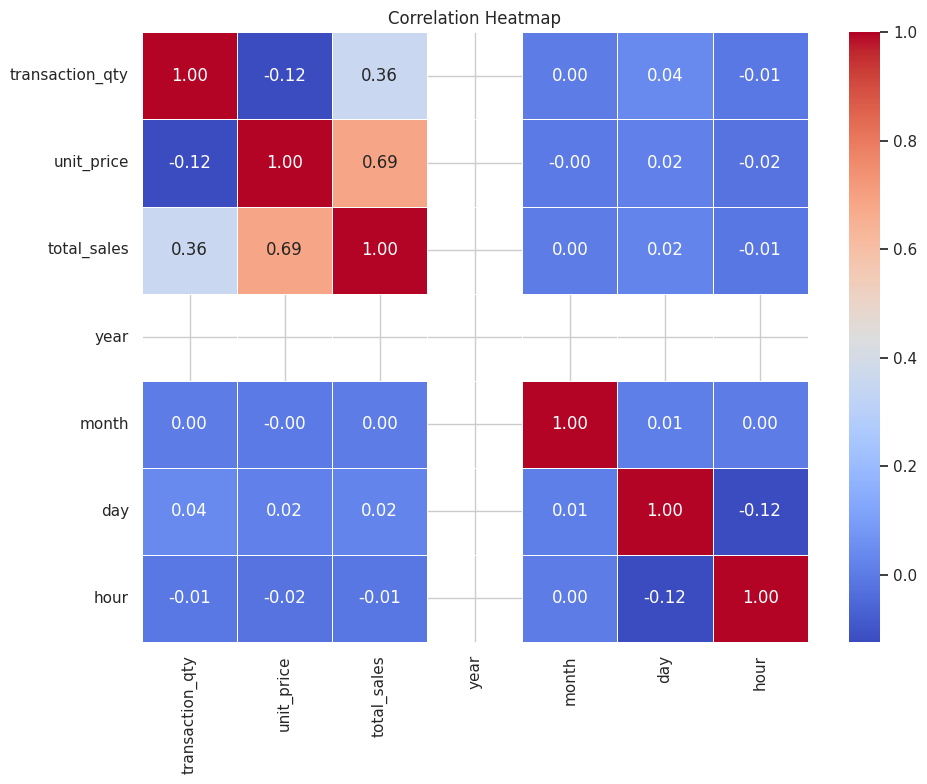

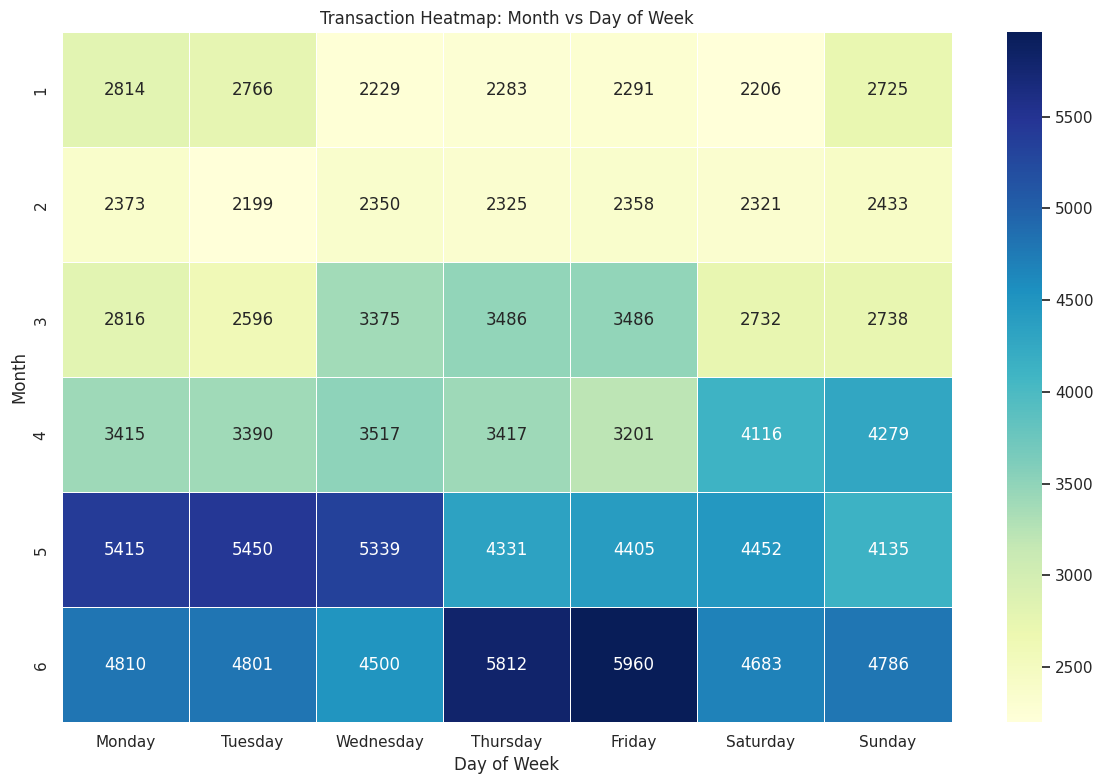

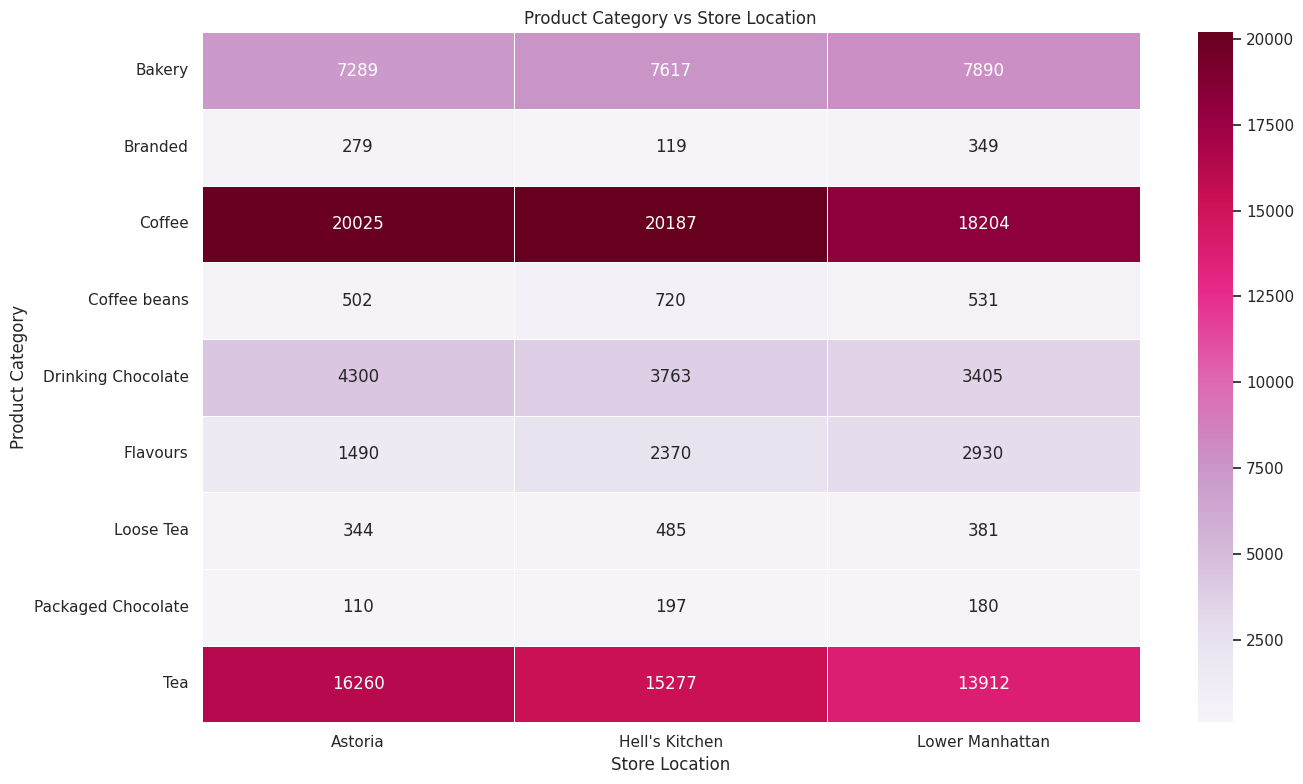


========== CATEGORY SALES SUMMARY ==========
                    transactions  quantity  average_price  total_sales
product_category                                                      
Coffee                     58416     89250       3.023646    269952.45
Tea                        45449     69737       2.817121    196405.95
Bakery                     22796     23214       3.551682     82315.64
Drinking Chocolate         11468     17457       4.148827     72416.00
Coffee beans                1753      1828      21.018397     40085.25
Branded                      747       776      17.720214     13607.00
Loose Tea                   1210      1210       9.267438     11213.60
Flavours                    6790     10511       0.800000      8408.80
Packaged Chocolate           487       487       9.050595      4407.64

========== PRODUCT TYPE SALES SUMMARY ==========
                       transactions  quantity  average_price  total_sales
product_type                                     

In [13]:
# Different colors for visualizations
colors = [
    "royalblue", "tomato", "seagreen", "orange",
    "purple", "crimson", "teal", "gold",
    "deeppink", "darkcyan", "slateblue", "coral"
]

# Improve visualization style
sns.set_theme(style="whitegrid")

# ============================================================
# 2. COPY DATASET
# ============================================================

# If your dataframe is already named df, use:
# df = df.copy()

df = df.copy()

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

# ============================================================
# 3. BASIC DATA INFORMATION
# ============================================================

print("\n========== DATA INFORMATION ==========")
print(df.info())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== DUPLICATE ROWS ==========")
print("Duplicates:", df.duplicated().sum())

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe(include="all").T)


# ============================================================
# 4. CONVERT DATE AND TIME
# ============================================================

df["transaction_date"] = pd.to_datetime(
    df["transaction_date"],
    errors="coerce"
)

df["transaction_time"] = pd.to_datetime(
    df["transaction_time"].astype(str),
    errors="coerce"
)

# Extract useful date/time features

df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["month_name"] = df["transaction_date"].dt.month_name()
df["day"] = df["transaction_date"].dt.day
df["day_name"] = df["transaction_date"].dt.day_name()
df["day_of_week"] = df["transaction_date"].dt.dayofweek

df["hour"] = df["transaction_time"].dt.hour

# Calculate total sales/revenue
df["total_sales"] = df["transaction_qty"] * df["unit_price"]

print("\n========== NEW FEATURES ==========")
print(df[
    [
        "transaction_date",
        "transaction_time",
        "year",
        "month",
        "month_name",
        "day_name",
        "hour",
        "total_sales"
    ]
].head())


# ============================================================
# 5. TRANSACTION QUANTITY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["transaction_qty"].dropna(),
    bins=30,
    color="royalblue",
    edgecolor="black"
)

plt.title("Distribution of Transaction Quantity", fontsize=16)
plt.xlabel("Transaction Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 6. UNIT PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["unit_price"].dropna(),
    bins=30,
    color="tomato",
    edgecolor="black"
)

plt.title("Distribution of Unit Price", fontsize=16)
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 7. TOTAL SALES DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["total_sales"].dropna(),
    bins=30,
    color="seagreen",
    edgecolor="black"
)

plt.title("Distribution of Total Sales", fontsize=16)
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 8. TOP STORE LOCATIONS BY TRANSACTION COUNT
# ============================================================

location_counts = (
    df["store_location"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

location_counts.sort_values().plot(
    kind="barh",
    color="orange",
    edgecolor="black"
)

plt.title("Top Store Locations by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Store Location")
plt.tight_layout()
plt.show()


# ============================================================
# 9. TRANSACTIONS BY STORE ID
# ============================================================

store_counts = (
    df["store_id"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12, 6))

plt.bar(
    store_counts.index.astype(str),
    store_counts.values,
    color="purple",
    edgecolor="black"
)

plt.title("Top Stores by Transaction Count")
plt.xlabel("Store ID")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 10. PRODUCT CATEGORY TRANSACTIONS
# ============================================================

category_counts = (
    df["product_category"]
    .value_counts()
)

plt.figure(figsize=(12, 6))

plt.bar(
    category_counts.index.astype(str),
    category_counts.values,
    color="crimson",
    edgecolor="black"
)

plt.title("Transactions by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 11. PRODUCT CATEGORY PIE CHART
# ============================================================

category_counts = df["product_category"].value_counts()

plt.figure(figsize=(9, 9))

plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[
        "royalblue",
        "tomato",
        "seagreen",
        "orange",
        "purple",
        "deeppink",
        "teal",
        "gold"
    ]
)

plt.title("Product Category Distribution")
plt.tight_layout()
plt.show()


# ============================================================
# 12. TOP PRODUCT TYPES
# ============================================================

product_type_counts = (
    df["product_type"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12, 7))

product_type_counts.sort_values().plot(
    kind="barh",
    color="teal",
    edgecolor="black"
)

plt.title("Top 15 Product Types by Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Product Type")
plt.tight_layout()
plt.show()


# ============================================================
# 13. TOP PRODUCT DETAILS
# ============================================================

product_detail_counts = (
    df["product_detail"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12, 7))

product_detail_counts.sort_values().plot(
    kind="barh",
    color="goldenrod",
    edgecolor="black"
)

plt.title("Top 15 Product Details")
plt.xlabel("Number of Transactions")
plt.ylabel("Product Detail")
plt.tight_layout()
plt.show()


# ============================================================
# 14. SALES BY PRODUCT CATEGORY
# ============================================================

category_sales = (
    df.groupby("product_category")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

plt.bar(
    category_sales.index.astype(str),
    category_sales.values,
    color="darkcyan",
    edgecolor="black"
)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 15. QUANTITY SOLD BY PRODUCT CATEGORY
# ============================================================

category_quantity = (
    df.groupby("product_category")["transaction_qty"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

plt.bar(
    category_quantity.index.astype(str),
    category_quantity.values,
    color="slateblue",
    edgecolor="black"
)

plt.title("Total Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 16. AVERAGE UNIT PRICE BY PRODUCT CATEGORY
# ============================================================

avg_price_category = (
    df.groupby("product_category")["unit_price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

plt.bar(
    avg_price_category.index.astype(str),
    avg_price_category.values,
    color="coral",
    edgecolor="black"
)

plt.title("Average Unit Price by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Unit Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 17. MONTHLY TRANSACTION TREND
# ============================================================

monthly_transactions = (
    df.groupby(df["transaction_date"].dt.to_period("M"))
    .size()
)

monthly_transactions.index = monthly_transactions.index.astype(str)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_transactions.index,
    monthly_transactions.values,
    marker="o",
    linewidth=2.5,
    color="royalblue"
)

plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 18. MONTHLY SALES TREND
# ============================================================

monthly_sales = (
    df.groupby(df["transaction_date"].dt.to_period("M"))["total_sales"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2.5,
    color="tomato"
)

plt.title("Monthly Total Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 19. MONTHLY QUANTITY TREND
# ============================================================

monthly_quantity = (
    df.groupby(df["transaction_date"].dt.to_period("M"))["transaction_qty"]
    .sum()
)

monthly_quantity.index = monthly_quantity.index.astype(str)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_quantity.index,
    monthly_quantity.values,
    marker="o",
    linewidth=2.5,
    color="seagreen"
)

plt.title("Monthly Quantity Sold Trend")
plt.xlabel("Month")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 20. SALES BY DAY OF WEEK
# ============================================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_sales = (
    df.groupby("day_name")["total_sales"]
    .sum()
    .reindex(day_order)
)

plt.figure(figsize=(11, 6))

plt.bar(
    day_sales.index,
    day_sales.values,
    color="purple",
    edgecolor="black"
)

plt.title("Total Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 21. TRANSACTIONS BY DAY OF WEEK
# ============================================================

day_transactions = (
    df["day_name"]
    .value_counts()
    .reindex(day_order)
)

plt.figure(figsize=(11, 6))

plt.bar(
    day_transactions.index,
    day_transactions.values,
    color="orange",
    edgecolor="black"
)

plt.title("Transactions by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 22. TRANSACTIONS BY HOUR
# ============================================================

hour_transactions = (
    df["hour"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    hour_transactions.index,
    hour_transactions.values,
    marker="o",
    linewidth=2.5,
    color="deeppink"
)

plt.title("Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


# ============================================================
# 23. SALES BY HOUR
# ============================================================

hour_sales = (
    df.groupby("hour")["total_sales"]
    .sum()
)

plt.figure(figsize=(12, 6))

plt.bar(
    hour_sales.index,
    hour_sales.values,
    color="darkcyan",
    edgecolor="black"
)

plt.title("Total Sales by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Sales")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


# ============================================================
# 24. TRANSACTION QUANTITY VS UNIT PRICE
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    df["unit_price"],
    df["transaction_qty"],
    alpha=0.5,
    color="red",
    edgecolor="black"
)

plt.title("Transaction Quantity vs Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Transaction Quantity")
plt.tight_layout()
plt.show()


# ============================================================
# 25. UNIT PRICE VS TOTAL SALES
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    df["unit_price"],
    df["total_sales"],
    alpha=0.5,
    color="blue",
    edgecolor="black"
)

plt.title("Unit Price vs Total Sales")
plt.xlabel("Unit Price")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()


# ============================================================
# 26. TRANSACTION QUANTITY VS TOTAL SALES
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    df["transaction_qty"],
    df["total_sales"],
    alpha=0.5,
    color="green",
    edgecolor="black"
)

plt.title("Transaction Quantity vs Total Sales")
plt.xlabel("Transaction Quantity")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()


# ============================================================
# 27. BOX PLOT - UNIT PRICE
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    y=df["unit_price"],
    color="violet"
)

plt.title("Box Plot of Unit Price")
plt.ylabel("Unit Price")
plt.tight_layout()
plt.show()


# ============================================================
# 28. BOX PLOT - TRANSACTION QUANTITY
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    y=df["transaction_qty"],
    color="lightgreen"
)

plt.title("Box Plot of Transaction Quantity")
plt.ylabel("Transaction Quantity")
plt.tight_layout()
plt.show()


# ============================================================
# 29. BOX PLOT - TOTAL SALES
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    y=df["total_sales"],
    color="lightcoral"
)

plt.title("Box Plot of Total Sales")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()


# ============================================================
# 30. TOP PRODUCTS BY TOTAL SALES
# ============================================================

top_products_sales = (
    df.groupby("product_detail")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

top_products_sales.sort_values().plot(
    kind="barh",
    color="royalblue",
    edgecolor="black"
)

plt.title("Top 15 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Detail")
plt.tight_layout()
plt.show()


# ============================================================
# 31. TOP PRODUCTS BY QUANTITY
# ============================================================

top_products_quantity = (
    df.groupby("product_detail")["transaction_qty"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

top_products_quantity.sort_values().plot(
    kind="barh",
    color="tomato",
    edgecolor="black"
)

plt.title("Top 15 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Detail")
plt.tight_layout()
plt.show()


# ============================================================
# 32. STORE LOCATION VS SALES
# ============================================================

location_sales = (
    df.groupby("store_location")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

location_sales.sort_values().plot(
    kind="barh",
    color="seagreen",
    edgecolor="black"
)

plt.title("Top Store Locations by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Store Location")
plt.tight_layout()
plt.show()


# ============================================================
# 33. STORE LOCATION VS QUANTITY
# ============================================================

location_quantity = (
    df.groupby("store_location")["transaction_qty"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

location_quantity.sort_values().plot(
    kind="barh",
    color="orange",
    edgecolor="black"
)

plt.title("Top Store Locations by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Store Location")
plt.tight_layout()
plt.show()


# ============================================================
# 34. CORRELATION HEATMAP
# ============================================================

numeric_columns = [
    "transaction_qty",
    "unit_price",
    "total_sales",
    "year",
    "month",
    "day",
    "hour"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# ============================================================
# 35. MONTH × DAY HEATMAP OF TRANSACTIONS
# ============================================================

month_day = pd.crosstab(
    df["month"],
    df["day_name"]
)

month_day = month_day.reindex(columns=day_order)

plt.figure(figsize=(12, 8))

sns.heatmap(
    month_day,
    annot=True,
    fmt="g",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Transaction Heatmap: Month vs Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Month")
plt.tight_layout()
plt.show()


# ============================================================
# 36. CATEGORY × STORE LOCATION HEATMAP
# ============================================================

category_location = pd.crosstab(
    df["product_category"],
    df["store_location"]
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    category_location,
    annot=True,
    fmt="g",
    cmap="PuRd",
    linewidths=0.5
)

plt.title("Product Category vs Store Location")
plt.xlabel("Store Location")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()


# ============================================================
# 37. CATEGORY SALES SUMMARY
# ============================================================

category_summary = (
    df.groupby("product_category")
    .agg(
        transactions=("transaction_id", "count"),
        quantity=("transaction_qty", "sum"),
        average_price=("unit_price", "mean"),
        total_sales=("total_sales", "sum")
    )
    .sort_values("total_sales", ascending=False)
)

print("\n========== CATEGORY SALES SUMMARY ==========")
print(category_summary)


# ============================================================
# 38. PRODUCT TYPE SALES SUMMARY
# ============================================================

product_type_summary = (
    df.groupby("product_type")
    .agg(
        transactions=("transaction_id", "count"),
        quantity=("transaction_qty", "sum"),
        average_price=("unit_price", "mean"),
        total_sales=("total_sales", "sum")
    )
    .sort_values("total_sales", ascending=False)
)

print("\n========== PRODUCT TYPE SALES SUMMARY ==========")
print(product_type_summary.head(20))


# ============================================================
# 39. STORE SUMMARY
# ============================================================

store_summary = (
    df.groupby("store_id")
    .agg(
        transactions=("transaction_id", "count"),
        quantity=("transaction_qty", "sum"),
        total_sales=("total_sales", "sum"),
        average_price=("unit_price", "mean")
    )
    .sort_values("total_sales", ascending=False)
)

print("\n========== STORE SUMMARY ==========")
print(store_summary.head(20))


# ============================================================
# 40. FINAL BUSINESS SUMMARY
# ============================================================

print("\n================================================")
print("              FINAL DATASET SUMMARY")
print("================================================")

print("Total Transactions :", df["transaction_id"].nunique())
print("Total Quantity     :", df["transaction_qty"].sum())
print("Total Sales        :", df["total_sales"].sum())
print("Average Unit Price :", df["unit_price"].mean())
print("Number of Stores   :", df["store_id"].nunique())
print("Number of Products :", df["product_id"].nunique())
print("Product Categories :", df["product_category"].nunique())
print("Product Types      :", df["product_type"].nunique())
print("Store Locations    :", df["store_location"].nunique())

print("\nTop Product Category:")
print(df["product_category"].value_counts().head(1))

print("\nTop Store Location:")
print(df["store_location"].value_counts().head(1))

print("\nTop Product Type:")
print(df["product_type"].value_counts().head(1))

print("\nTop Product:")
print(df["product_detail"].value_counts().head(1))

print("\n================================================")
print("         VISUALIZATION ANALYSIS COMPLETED")
print("================================================")

## Feature engineering

Dataset Shape:
(149116, 19)

Dataset Columns:
['transaction_id', 'transaction_date', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail', 'year', 'month', 'month_name', 'day', 'day_name', 'day_of_week', 'hour', 'total_sales']

First 5 Rows:
   transaction_id transaction_date    transaction_time  transaction_qty  \
0               1       2023-01-01 2026-09-22 07:06:11                2   
1               2       2023-01-01 2026-09-22 07:08:56                2   
2               3       2023-01-01 2026-09-22 07:14:04                2   
3               4       2023-01-01 2026-09-22 07:20:24                1   
4               5       2023-01-01 2026-09-22 07:22:41                2   

   store_id   store_location  product_id  unit_price    product_category  \
0         5  Lower Manhattan          32         3.0              Coffee   
1         5  Lower Manhattan          57         3.1      

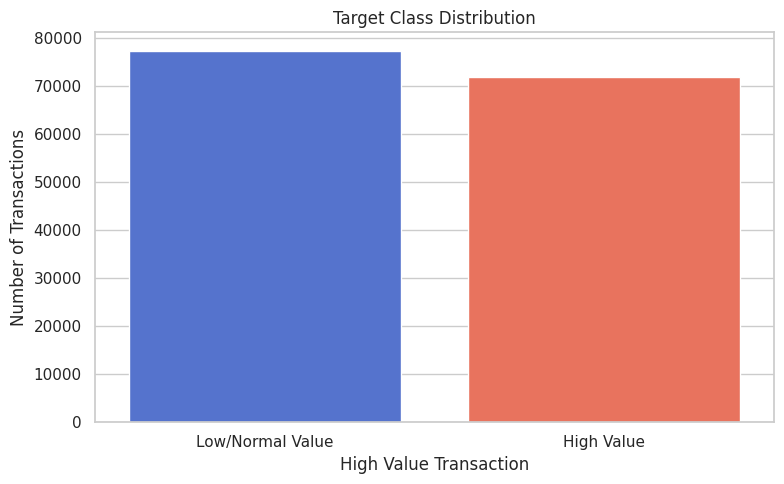


================ LABEL ENCODING EXAMPLE ================
   transaction_qty  unit_price  transaction_year  transaction_month  \
0                2         3.0              2023                  1   
1                2         3.1              2023                  1   
2                2         4.5              2023                  1   
3                1         2.0              2023                  1   
4                2         3.1              2023                  1   

   transaction_day  transaction_dayofweek  transaction_hour  \
0                1                      6                 7   
1                1                      6                 7   
2                1                      6                 7   
3                1                      6                 7   
4                1                      6                 7   

   transaction_minute  store_id  store_location  product_id  product_category  \
0                   6         1               2        

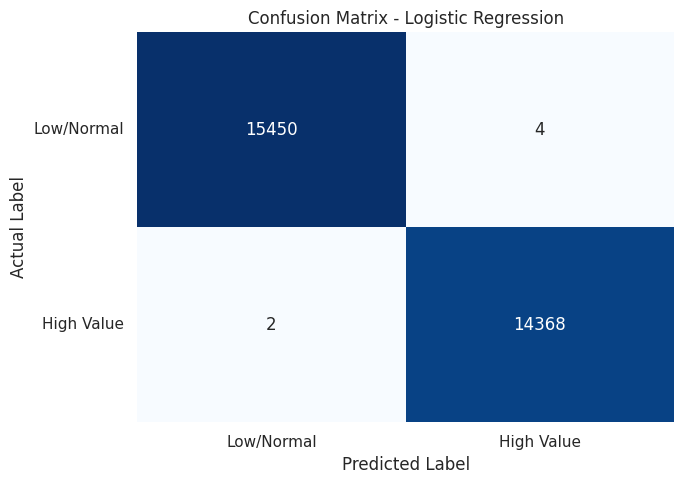



TRAINING: Decision Tree

Accuracy:
1.0

Precision:
1.0

Recall:
1.0

F1 Score:
1.0

ROC-AUC:
1.0

================ CLASSIFICATION REPORT ================
                  precision    recall  f1-score   support

Low/Normal Value       1.00      1.00      1.00     15454
      High Value       1.00      1.00      1.00     14370

        accuracy                           1.00     29824
       macro avg       1.00      1.00      1.00     29824
    weighted avg       1.00      1.00      1.00     29824



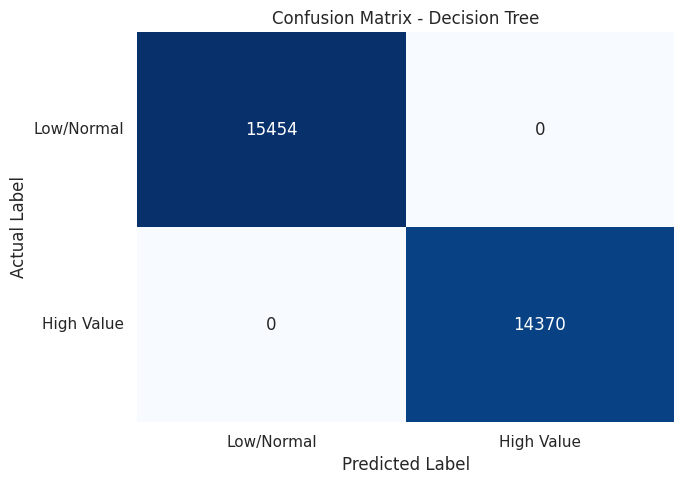



TRAINING: Random Forest

Accuracy:
1.0

Precision:
1.0

Recall:
1.0

F1 Score:
1.0

ROC-AUC:
1.0

================ CLASSIFICATION REPORT ================
                  precision    recall  f1-score   support

Low/Normal Value       1.00      1.00      1.00     15454
      High Value       1.00      1.00      1.00     14370

        accuracy                           1.00     29824
       macro avg       1.00      1.00      1.00     29824
    weighted avg       1.00      1.00      1.00     29824



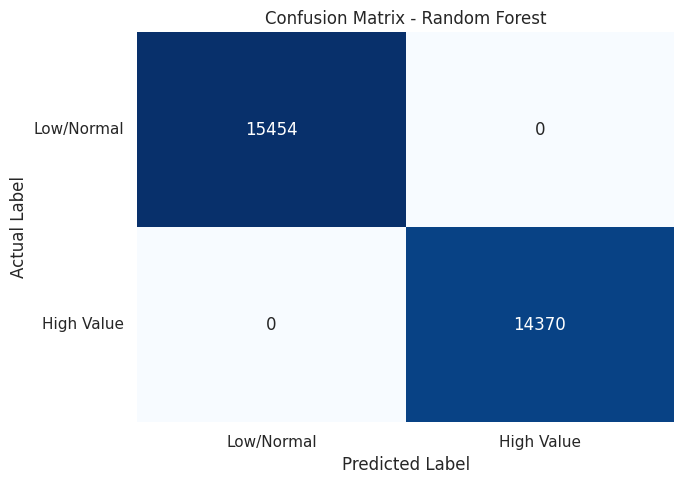



TRAINING: Gradient Boosting

Accuracy:
1.0

Precision:
1.0

Recall:
1.0

F1 Score:
1.0

ROC-AUC:
1.0

================ CLASSIFICATION REPORT ================
                  precision    recall  f1-score   support

Low/Normal Value       1.00      1.00      1.00     15454
      High Value       1.00      1.00      1.00     14370

        accuracy                           1.00     29824
       macro avg       1.00      1.00      1.00     29824
    weighted avg       1.00      1.00      1.00     29824



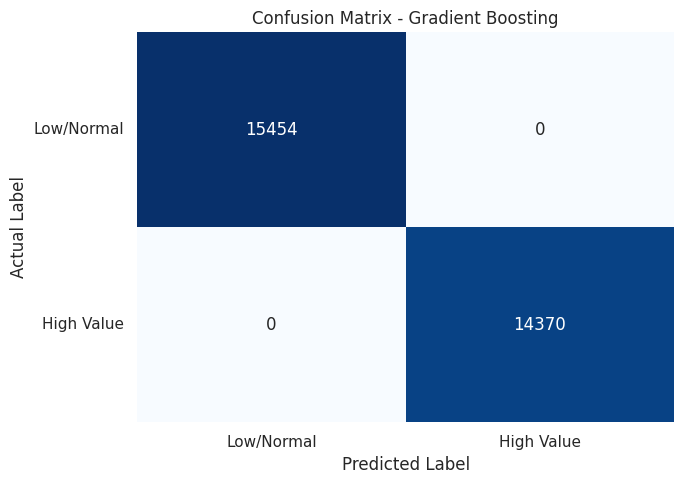



TRAINING: Extra Trees

Accuracy:
0.9996982296137339

Precision:
1.0

Recall:
0.9993736951983299

F1 Score:
0.99968674950402

ROC-AUC:
0.9999196529012538

================ CLASSIFICATION REPORT ================
                  precision    recall  f1-score   support

Low/Normal Value       1.00      1.00      1.00     15454
      High Value       1.00      1.00      1.00     14370

        accuracy                           1.00     29824
       macro avg       1.00      1.00      1.00     29824
    weighted avg       1.00      1.00      1.00     29824



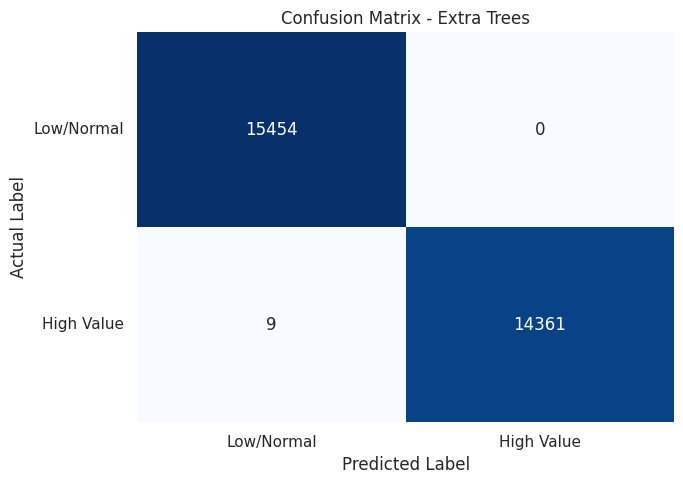



TRAINING: KNN

Accuracy:
0.9984240879828327

Precision:
1.0

Recall:
0.9967292971468337

F1 Score:
0.9983619698184226

ROC-AUC:
0.9990872996467213

================ CLASSIFICATION REPORT ================
                  precision    recall  f1-score   support

Low/Normal Value       1.00      1.00      1.00     15454
      High Value       1.00      1.00      1.00     14370

        accuracy                           1.00     29824
       macro avg       1.00      1.00      1.00     29824
    weighted avg       1.00      1.00      1.00     29824



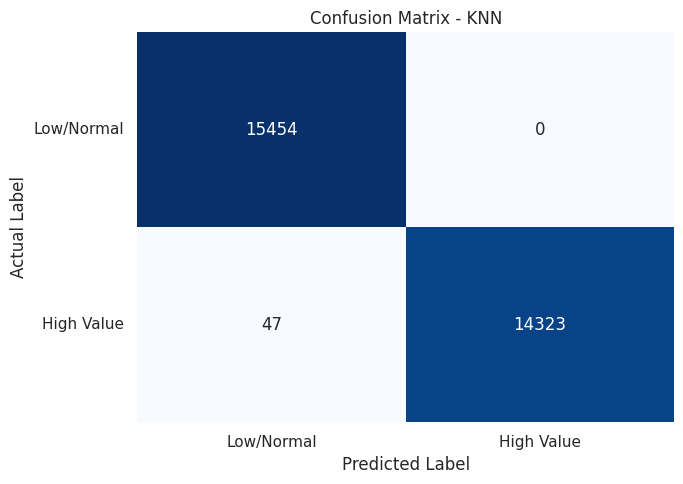



                    MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
      Decision Tree  1.000000   1.000000 1.000000  1.000000 1.000000
      Random Forest  1.000000   1.000000 1.000000  1.000000 1.000000
  Gradient Boosting  1.000000   1.000000 1.000000  1.000000 1.000000
Logistic Regression  0.999799   0.999722 0.999861  0.999791 1.000000
        Extra Trees  0.999698   1.000000 0.999374  0.999687 0.999920
                KNN  0.998424   1.000000 0.996729  0.998362 0.999087


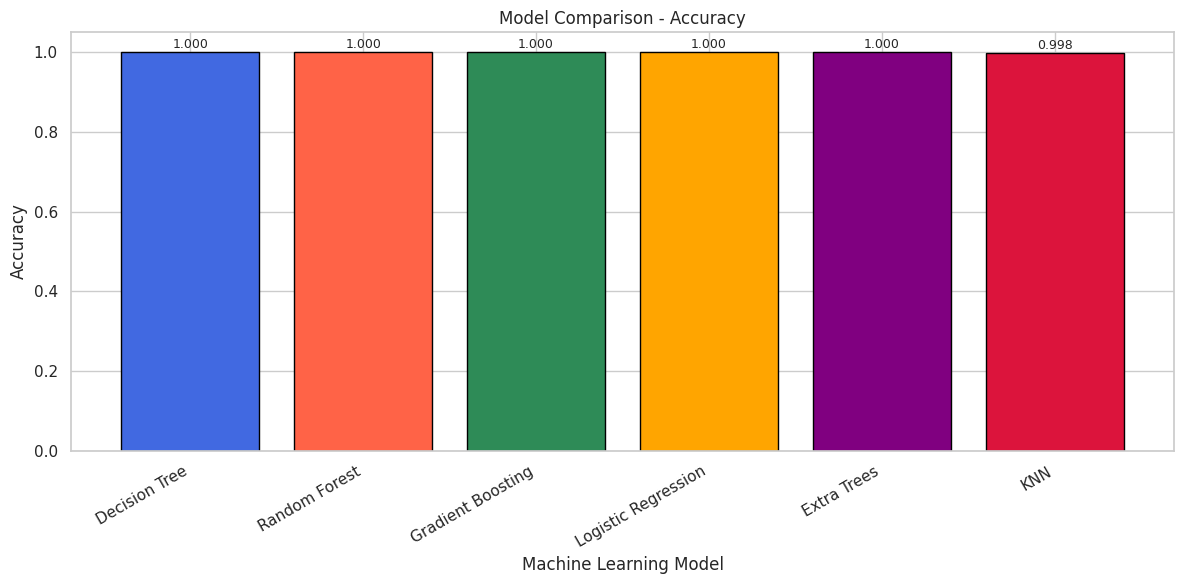

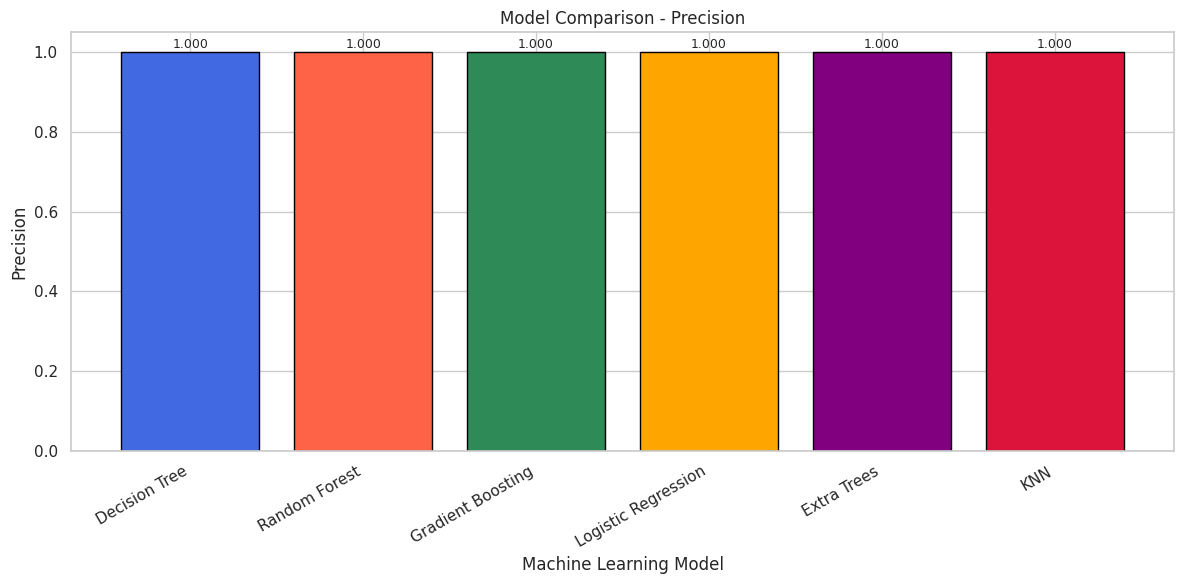

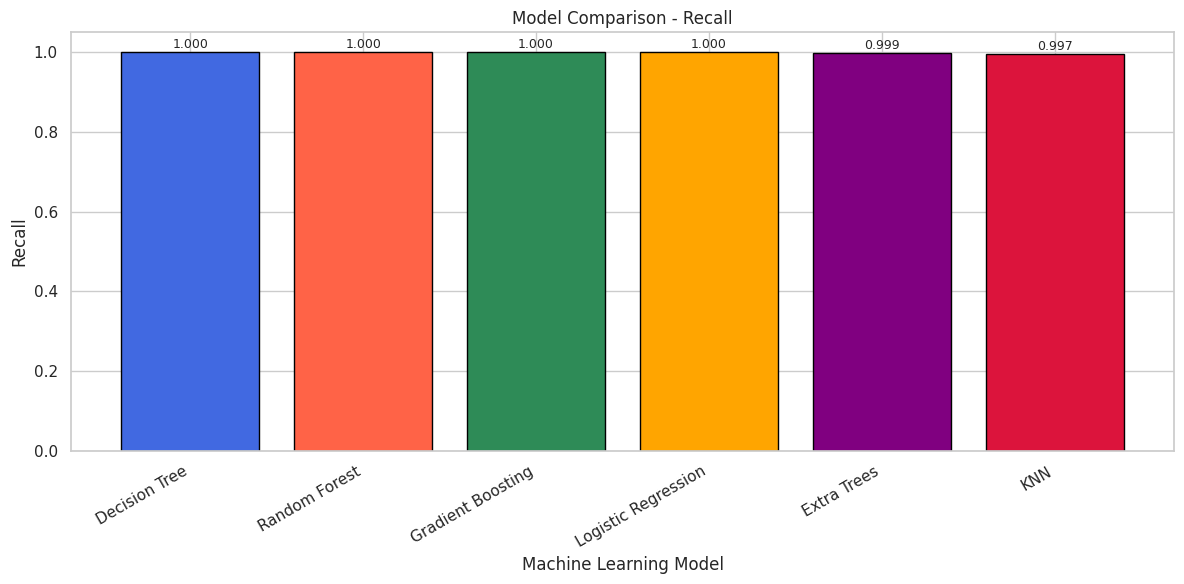

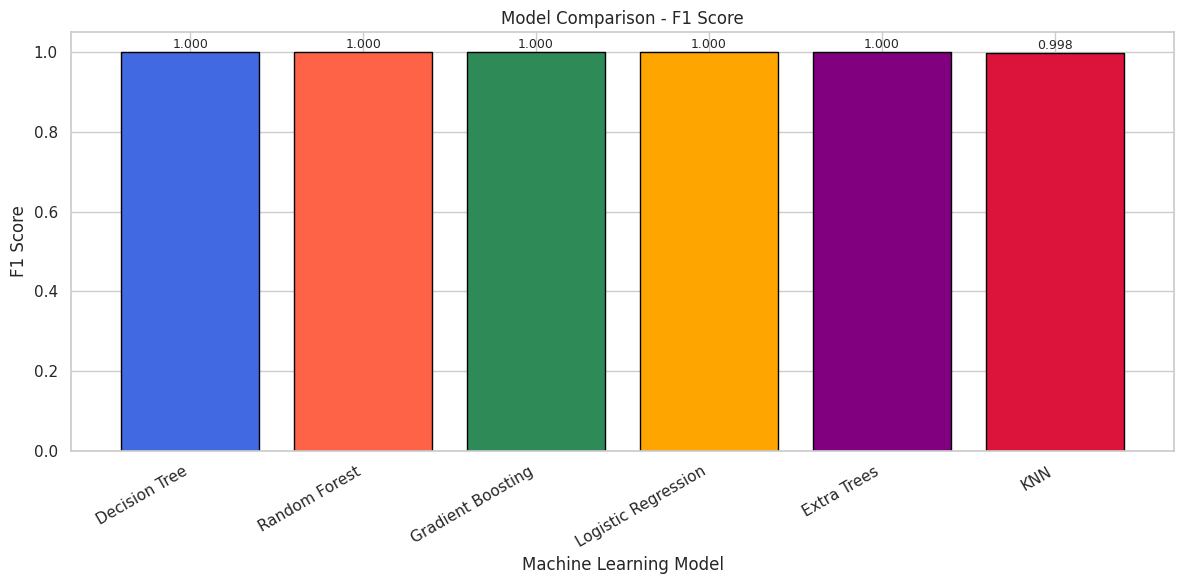

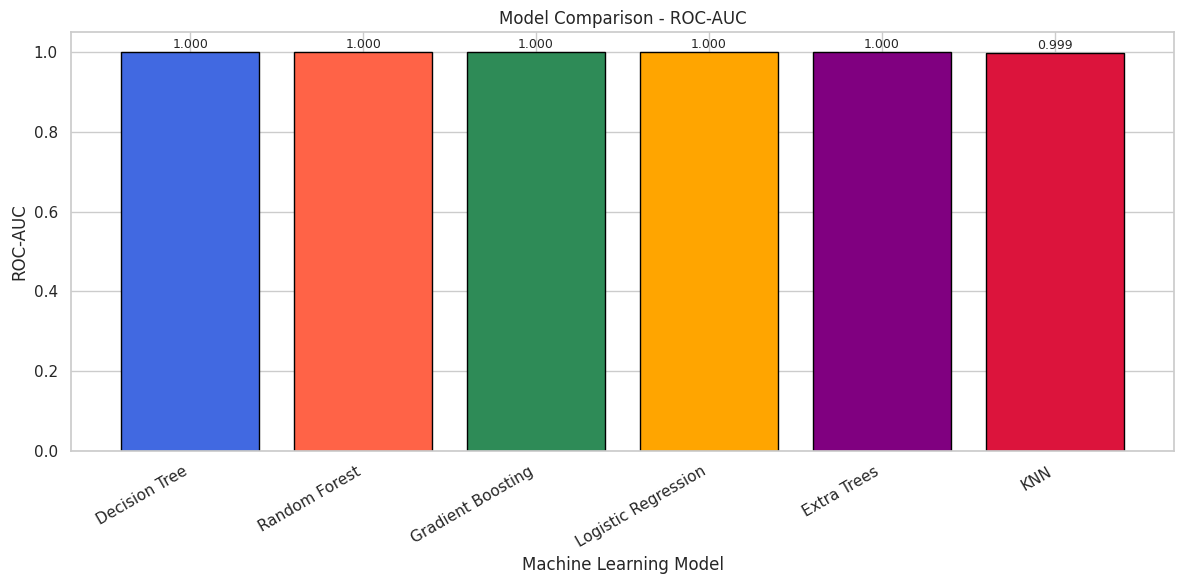

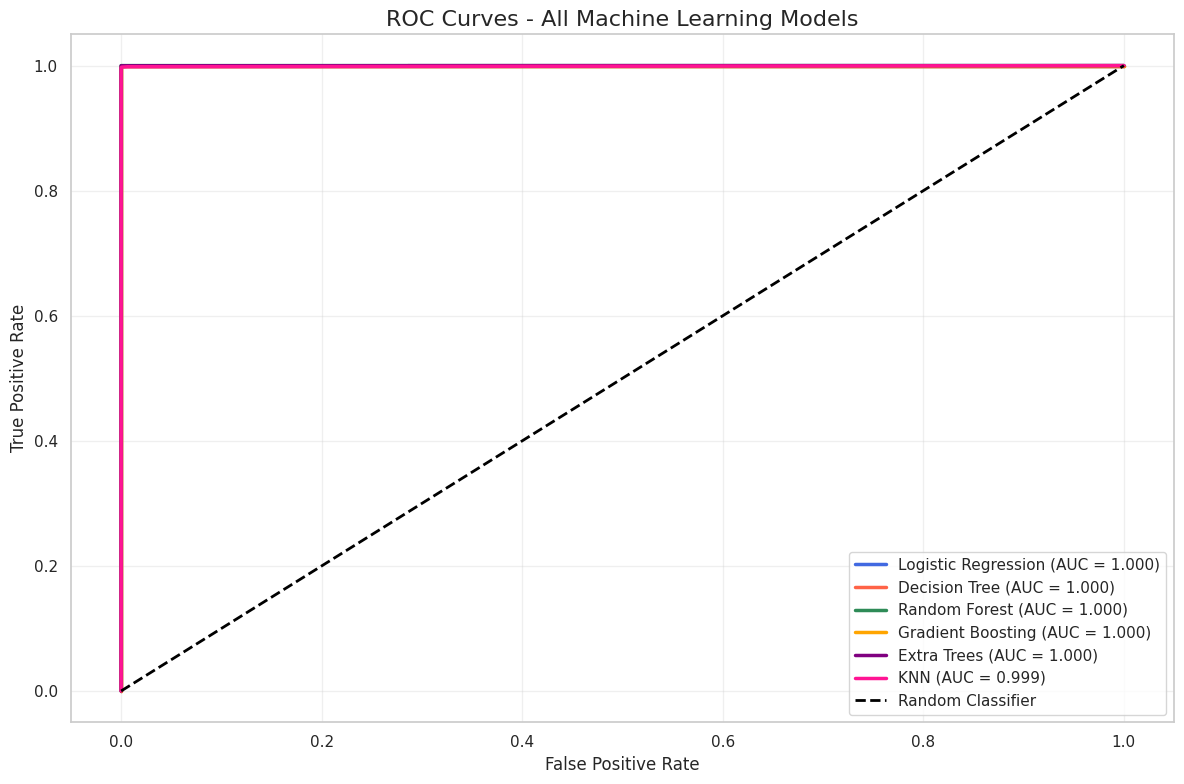

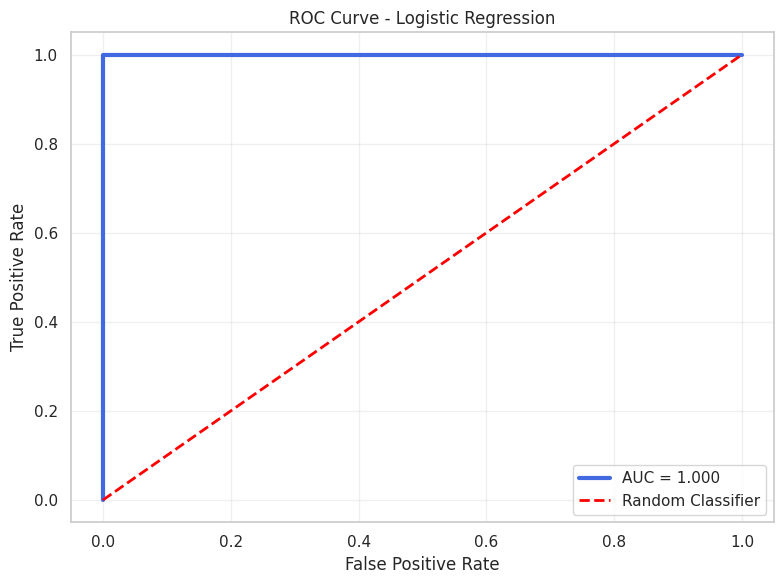

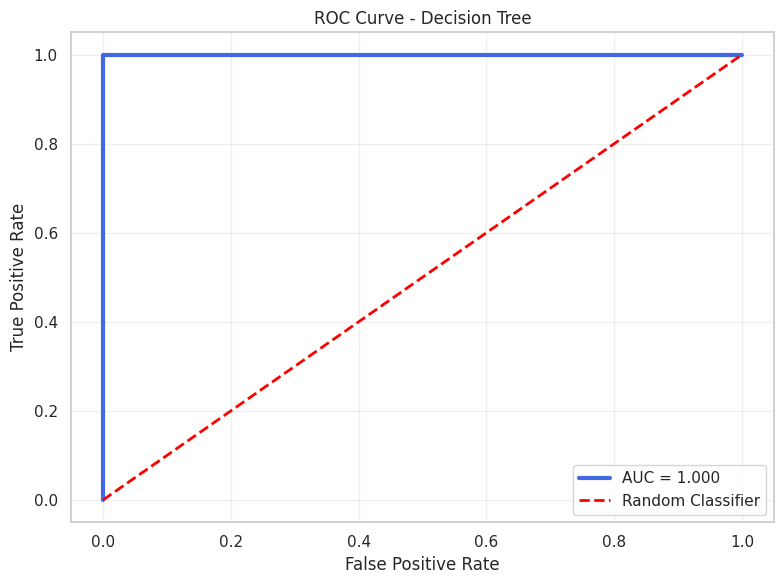

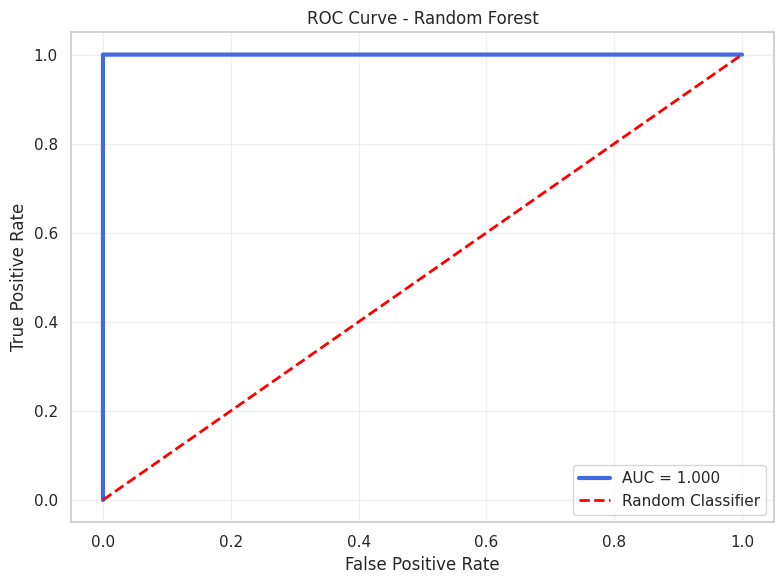

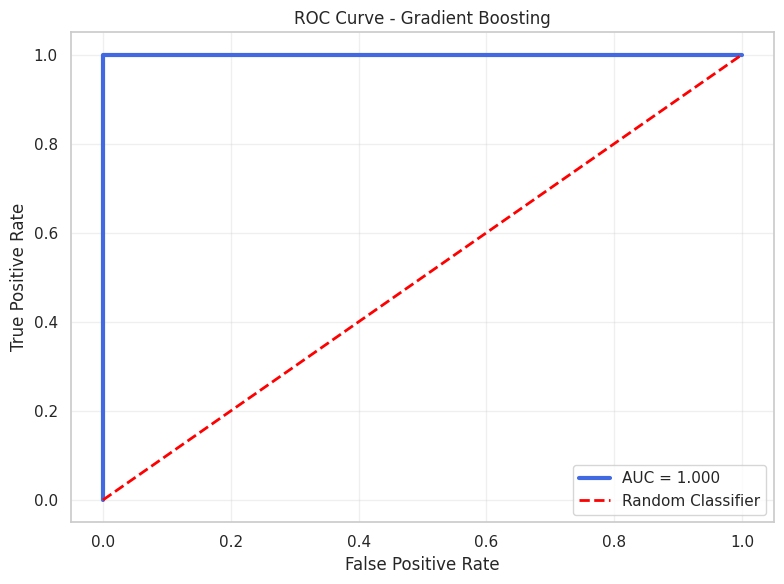

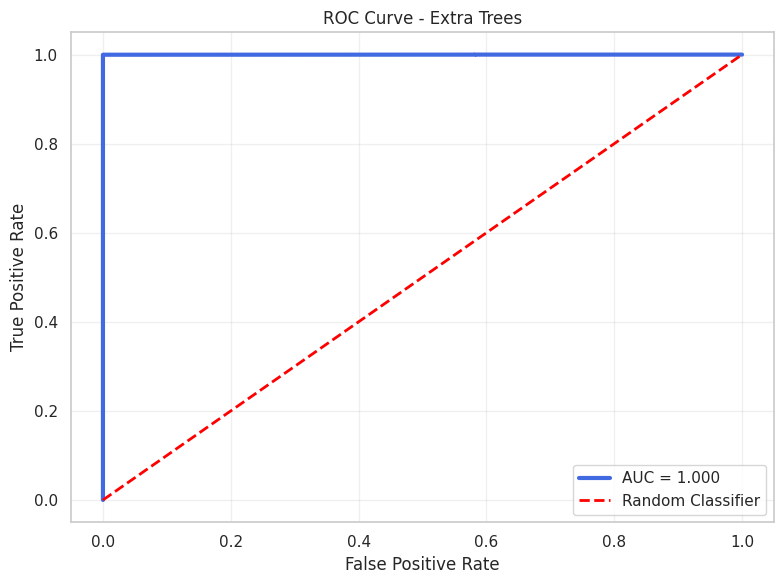

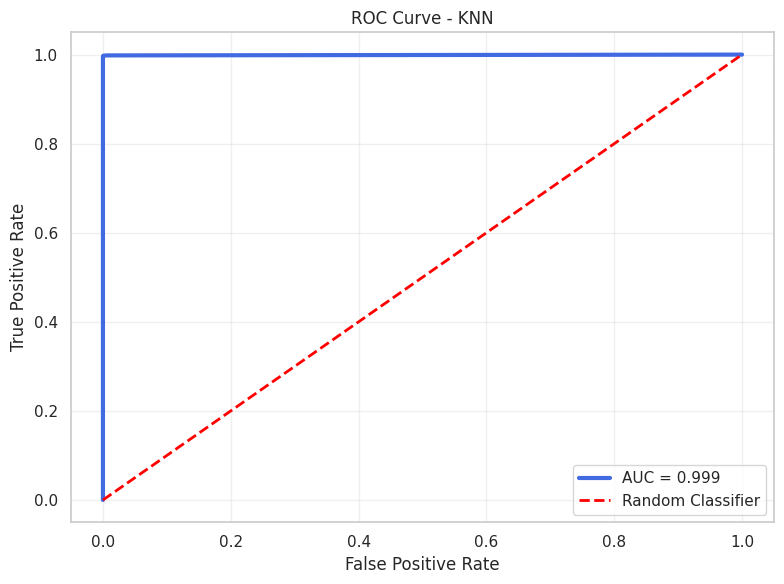



                       FINAL RESULTS
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
      Decision Tree    1.0000     1.0000  1.0000    1.0000   1.0000
      Random Forest    1.0000     1.0000  1.0000    1.0000   1.0000
  Gradient Boosting    1.0000     1.0000  1.0000    1.0000   1.0000
Logistic Regression    0.9998     0.9997  0.9999    0.9998   1.0000
        Extra Trees    0.9997     1.0000  0.9994    0.9997   0.9999
                KNN    0.9984     1.0000  0.9967    0.9984   0.9991


Highest ROC-AUC Model: Decision Tree
ROC-AUC: 1.0

Model comparison saved as: ml_model_comparison_results.csv


                    PROJECT COMPLETED
1. Data Cleaning                  ✓
2. Date Feature Engineering      ✓
3. Time Feature Engineering      ✓
4. Total Sales Calculation       ✓
5. Target Creation               ✓
6. Label Encoding                ✓
7. Train-Test Split              ✓
8. One-Hot Encoding              ✓
9. Feature Scaling               ✓
10. Logistic Regr

In [14]:
# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ============================================================
# 2. LOAD / COPY DATA
# ============================================================

# If your dataframe is already loaded as df:
df = df.copy()

print("Dataset Shape:")
print(df.shape)

print("\nDataset Columns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 3. BASIC DATA INFORMATION
# ============================================================

print("\n================ DATA INFORMATION ================")

print(df.info())

print("\n================ MISSING VALUES ================")

print(df.isnull().sum())

print("\n================ DUPLICATE ROWS ================")

print("Duplicate rows:", df.duplicated().sum())


# ============================================================
# 4. REMOVE DUPLICATE ROWS
# ============================================================

df = df.drop_duplicates().reset_index(drop=True)

print("\nShape after removing duplicates:")
print(df.shape)


# ============================================================
# 5. CONVERT DATE COLUMN
# ============================================================

df["transaction_date"] = pd.to_datetime(
    df["transaction_date"],
    errors="coerce"
)


# ============================================================
# 6. CONVERT TIME COLUMN
# ============================================================

# Convert transaction_time into datetime
time_temp = pd.to_datetime(
    df["transaction_time"].astype(str),
    errors="coerce"
)

df["transaction_hour"] = time_temp.dt.hour
df["transaction_minute"] = time_temp.dt.minute
df["transaction_second"] = time_temp.dt.second


# ============================================================
# 7. CREATE DATE FEATURES
# ============================================================

df["transaction_year"] = df["transaction_date"].dt.year

df["transaction_month"] = df["transaction_date"].dt.month

df["transaction_day"] = df["transaction_date"].dt.day

df["transaction_dayofweek"] = (
    df["transaction_date"].dt.dayofweek
)


# ============================================================
# 8. CREATE TOTAL SALES
# ============================================================

df["total_sales"] = (
    df["transaction_qty"] *
    df["unit_price"]
)

print("\nTotal Sales Created Successfully.")


# ============================================================
# 9. CREATE TARGET VARIABLE
# ============================================================
#
# There is no target column in the original dataset.
#
# We create:
#
# high_value_transaction
#
# 1 = transaction total is above median
# 0 = transaction total is below/equal median
#
# ============================================================

sales_median = df["total_sales"].median()

df["high_value_transaction"] = (
    df["total_sales"] > sales_median
).astype(int)

print("\nMedian Transaction Value:")
print(sales_median)

print("\nTarget Distribution:")
print(df["high_value_transaction"].value_counts())


# ============================================================
# 10. CHECK TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    x=df["high_value_transaction"],
    hue=df["high_value_transaction"],
    palette=["royalblue", "tomato"],
    legend=False
)

plt.title("Target Class Distribution")
plt.xlabel("High Value Transaction")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Low/Normal Value", "High Value"]
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. REMOVE DATA LEAKAGE
# ============================================================
#
# IMPORTANT:
#
# total_sales was used to CREATE the target.
# Therefore total_sales must NOT be used as an input feature.
#
# transaction_qty and unit_price are retained because they
# represent the original transaction characteristics.
#
# ============================================================


# ============================================================
# 12. SELECT FEATURES
# ============================================================

feature_columns = [
    "transaction_qty",
    "unit_price",
    "transaction_year",
    "transaction_month",
    "transaction_day",
    "transaction_dayofweek",
    "transaction_hour",
    "transaction_minute",
    "store_id",
    "store_location",
    "product_id",
    "product_category",
    "product_type",
    "product_detail"
]

X = df[feature_columns].copy()

y = df["high_value_transaction"].copy()


# ============================================================
# 13. HANDLE MISSING VALUES
# ============================================================

# Numeric columns
numeric_columns = [
    "transaction_qty",
    "unit_price",
    "transaction_year",
    "transaction_month",
    "transaction_day",
    "transaction_dayofweek",
    "transaction_hour",
    "transaction_minute"
]

# Categorical columns
categorical_columns = [
    "store_id",
    "store_location",
    "product_id",
    "product_category",
    "product_type",
    "product_detail"
]


# ============================================================
# 14. FILL MISSING VALUES
# ============================================================

for column in numeric_columns:

    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )

    X[column] = X[column].fillna(
        X[column].median()
    )


for column in categorical_columns:

    X[column] = X[column].astype(str)

    X[column] = X[column].replace(
        ["nan", "None", "NaT"],
        "Unknown"
    )

    X[column] = X[column].fillna("Unknown")


# ============================================================
# 15. LABEL ENCODING
# ============================================================
#
# LabelEncoder is demonstrated here.
#
# However, for the ML pipeline we use OneHotEncoder because
# store/product/category variables are nominal categories.
#
# ============================================================

label_encoded_df = X.copy()

label_encoders = {}

for column in categorical_columns:

    le = LabelEncoder()

    label_encoded_df[column] = le.fit_transform(
        label_encoded_df[column].astype(str)
    )

    label_encoders[column] = le


print("\n================ LABEL ENCODING EXAMPLE ================")

print(label_encoded_df.head())


# ============================================================
# 16. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n================ TRAIN TEST SPLIT ================")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ============================================================
# 17. PREPROCESSING
# ============================================================
#
# Numeric:
# StandardScaler
#
# Categorical:
# OneHotEncoder
#
# handle_unknown="ignore" prevents errors if a category
# appears in test data but wasn't present in training data.
#
# ============================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",
            StandardScaler(),
            numeric_columns
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)


# ============================================================
# 18. DEFINE MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=10,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        )
}


# ============================================================
# 19. TRAIN MODELS
# ============================================================

results = []

trained_models = {}

roc_data = {}


for model_name, model in models.items():

    print("\n")
    print("=" * 70)
    print("TRAINING:", model_name)
    print("=" * 70)

    # Create pipeline
    pipeline = Pipeline(

        steps=[

            (
                "preprocessing",
                preprocessor
            ),

            (
                "model",
                model
            )
        ]
    )

    # Train
    pipeline.fit(
        X_train,
        y_train
    )

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Probability predictions
    y_probability = pipeline.predict_proba(
        X_test
    )[:, 1]

    # ========================================================
    # METRICS
    # ========================================================

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_probability
    )

    # Store results
    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC-AUC": auc
    })

    trained_models[model_name] = pipeline

    # ROC data
    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_probability
    )

    roc_data[model_name] = {

        "fpr": fpr,

        "tpr": tpr,

        "auc": auc
    }

    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print("\nAccuracy:")
    print(accuracy)

    print("\nPrecision:")
    print(precision)

    print("\nRecall:")
    print(recall)

    print("\nF1 Score:")
    print(f1)

    print("\nROC-AUC:")
    print(auc)

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\n================ CLASSIFICATION REPORT ================")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Low/Normal Value",
                "High Value"
            ],
            zero_division=0
        )
    )

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted Label")

    plt.ylabel("Actual Label")

    plt.xticks(
        [0.5, 1.5],
        [
            "Low/Normal",
            "High Value"
        ]
    )

    plt.yticks(
        [0.5, 1.5],
        [
            "Low/Normal",
            "High Value"
        ],
        rotation=0
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 20. CREATE RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

print("\n")
print("=" * 80)
print("                    MODEL COMPARISON")
print("=" * 80)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 21. MODEL COMPARISON BAR CHART
# ============================================================

metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

for metric in metrics_to_plot:

    plt.figure(figsize=(12, 6))

    bars = plt.bar(
        results_df["Model"],
        results_df[metric],
        color=[
            "royalblue",
            "tomato",
            "seagreen",
            "orange",
            "purple",
            "crimson"
        ][:len(results_df)],
        edgecolor="black"
    )

    plt.title(
        f"Model Comparison - {metric}"
    )

    plt.xlabel("Machine Learning Model")

    plt.ylabel(metric)

    plt.ylim(
        0,
        1.05
    )

    plt.xticks(
        rotation=30,
        ha="right"
    )

    # Add values on bars
    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            fontsize=9
        )

    plt.tight_layout()

    plt.show()


# ============================================================
# 22. COMPLETE ROC CURVE
# ============================================================

plt.figure(figsize=(12, 8))

roc_colors = [
    "royalblue",
    "tomato",
    "seagreen",
    "orange",
    "purple",
    "deeppink"
]

for (model_name, data), color in zip(
    roc_data.items(),
    roc_colors
):

    plt.plot(
        data["fpr"],
        data["tpr"],
        color=color,
        linewidth=2.5,
        label=f"{model_name} (AUC = {data['auc']:.3f})"
    )


# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)


plt.title(
    "ROC Curves - All Machine Learning Models",
    fontsize=16
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 23. INDIVIDUAL ROC CURVES
# ============================================================

for model_name, data in roc_data.items():

    plt.figure(figsize=(8, 6))

    plt.plot(
        data["fpr"],
        data["tpr"],
        color="royalblue",
        linewidth=3,
        label=f"AUC = {data['auc']:.3f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        color="red",
        linestyle="--",
        linewidth=2,
        label="Random Classifier"
    )

    plt.title(
        f"ROC Curve - {model_name}"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.legend(
        loc="lower right"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 24. FINAL MODEL RESULTS
# ============================================================

print("\n")
print("=" * 90)
print("                       FINAL RESULTS")
print("=" * 90)

print(
    results_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ]
    ].round(4).to_string(index=False)
)


# ============================================================
# 25. BEST MODEL BASED ON ROC-AUC
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_auc = results_df.iloc[0]["ROC-AUC"]

print("\n")
print("=" * 70)

print(
    "Highest ROC-AUC Model:",
    best_model_name
)

print(
    "ROC-AUC:",
    round(best_auc, 4)
)

print("=" * 70)


# ============================================================
# 26. SAVE MODEL RESULTS
# ============================================================

results_df.to_csv(
    "ml_model_comparison_results.csv",
    index=False
)

print(
    "\nModel comparison saved as: "
    "ml_model_comparison_results.csv"
)


# ============================================================
# 27. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("                    PROJECT COMPLETED")
print("=" * 80)

print("1. Data Cleaning                  ✓")
print("2. Date Feature Engineering      ✓")
print("3. Time Feature Engineering      ✓")
print("4. Total Sales Calculation       ✓")
print("5. Target Creation               ✓")
print("6. Label Encoding                ✓")
print("7. Train-Test Split              ✓")
print("8. One-Hot Encoding              ✓")
print("9. Feature Scaling               ✓")
print("10. Logistic Regression          ✓")
print("11. Decision Tree                ✓")
print("12. Random Forest                ✓")
print("13. Gradient Boosting             ✓")
print("14. Extra Trees                  ✓")
print("15. KNN                           ✓")
print("16. Accuracy                     ✓")
print("17. Precision                    ✓")
print("18. Recall                       ✓")
print("19. F1 Score                     ✓")
print("20. Confusion Matrix             ✓")
print("21. Classification Report        ✓")
print("22. ROC Curve                    ✓")
print("23. ROC-AUC                      ✓")
print("24. Model Comparison             ✓")

print("=" * 80)

## THank you..pls upvote!!!!!!!!!!!